# 🛍️ Product Image Classification
### CNN-Based E-Commerce Product Categorisation using Transfer Learning & Explainability
---
**Models:** Custom CNN · MobileNetV2 · ResNet50  
**Explainability:** Grad-CAM · SHAP  
**Dataset:** [Fashion Products Images – Kaggle](https://www.kaggle.com/datasets/bhavikjikadara/e-commerce-products-images)


---
## 📦 Step 1: Install & Import Libraries

In [1]:
import os, random, warnings, time, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import shap

from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50    import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs       : {tf.config.list_physical_devices('GPU')}")


2026-07-08 08:59:49.682718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783501189.884582      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783501189.955294      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783501190.494282      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783501190.494325      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783501190.494329      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📂 Step 2: Dataset Loading & Exploration

In [2]:
BASE_DIR   = Path('/kaggle/input/datasets/bhavikjikadara/e-commerce-products-images')
IMAGE_DIR  = BASE_DIR / 'e-commerce' / 'images'
OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR  exists : {BASE_DIR.exists()}")
print(f"IMAGE_DIR exists : {IMAGE_DIR.exists()}")
print(f"OUTPUT_DIR       : {OUTPUT_DIR}")


BASE_DIR  exists : True
IMAGE_DIR exists : True
OUTPUT_DIR       : /kaggle/working/outputs


In [3]:
df = pd.read_csv(BASE_DIR / 'styles.csv', on_bad_lines='skip')
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
df.head()


Shape   : (44441, 10)
Columns : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44441 non-null  int64  
 1   gender              44441 non-null  object 
 2   masterCategory      44441 non-null  object 
 3   subCategory         44441 non-null  object 
 4   articleType         44441 non-null  object 
 5   baseColour          44426 non-null  object 
 6   season              44420 non-null  object 
 7   year                44440 non-null  float64
 8   usage               44124 non-null  object 
 9   productDisplayName  44434 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB
None

Missing values:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage      

In [5]:
LABEL_COL = 'masterCategory'

df['image_path'] = df['id'].astype(str).apply(lambda x: str(IMAGE_DIR / f"{x}.jpg"))
df['exists']     = df['image_path'].apply(os.path.exists)
df               = df[df['exists']].drop(columns='exists').reset_index(drop=True)
print(f"Images found on disk: {len(df):,}")


Images found on disk: 44,441


Classes : 7
masterCategory
Apparel           21395
Accessories       11289
Footwear           9222
Personal Care      2404
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


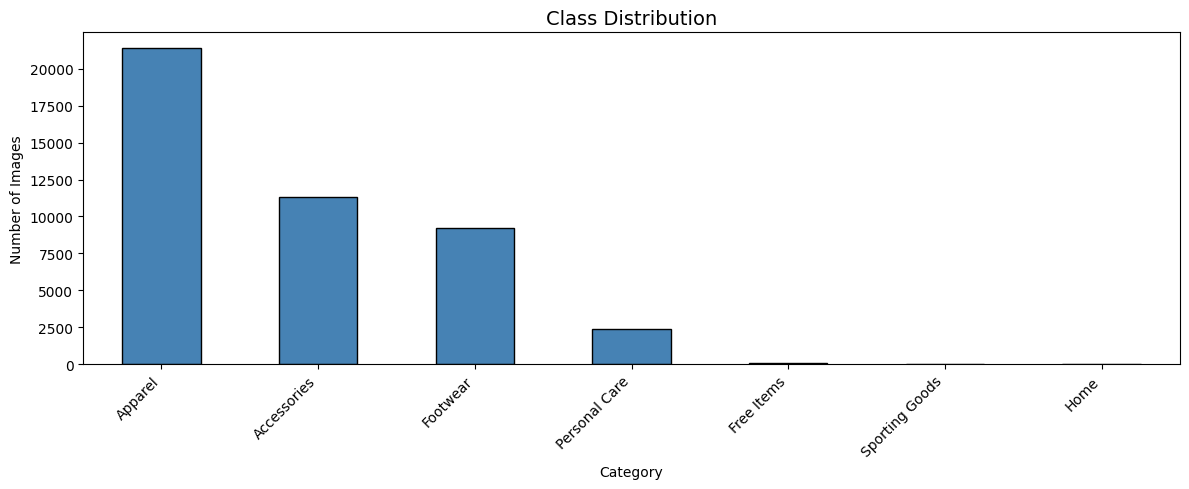

In [6]:
class_counts = df[LABEL_COL].value_counts()
print(f"Classes : {len(class_counts)}")
print(class_counts)

plt.figure(figsize=(12, 5))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Category'); plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.pdf', dpi=150)
plt.show()


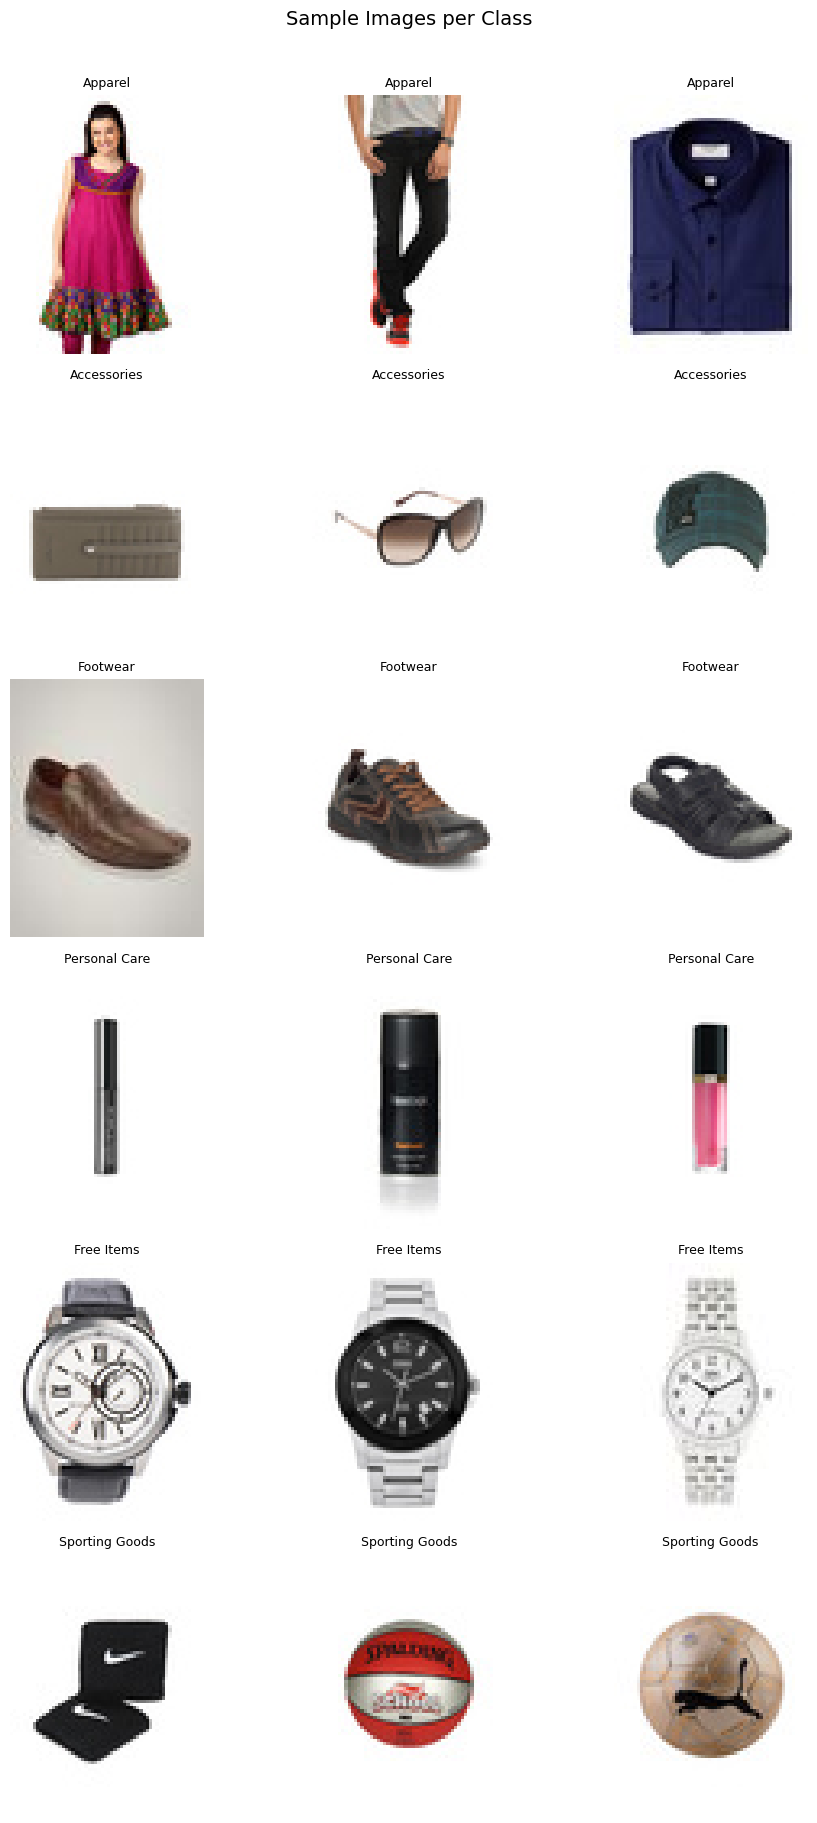

In [7]:
classes = class_counts.index.tolist()
fig, axes = plt.subplots(min(len(classes), 6), 3, figsize=(10, min(len(classes), 6) * 3))
axes = axes.flatten()
ax_idx = 0
for cls in classes[:6]:
    for _, row in df[df[LABEL_COL] == cls].sample(3, random_state=SEED).iterrows():
        axes[ax_idx].imshow(Image.open(row['image_path']).convert('RGB'))
        axes[ax_idx].set_title(cls, fontsize=9); axes[ax_idx].axis('off')
        ax_idx += 1
plt.suptitle('Sample Images per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## ✂️ Step 3: Preprocessing & Train / Val / Test Split

In [8]:
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
EPOCHS_CNN = 30
EPOCHS_TL  = 20

MIN_SAMPLES   = 50
class_counts  = df[LABEL_COL].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index.tolist()
df_filtered   = df[df[LABEL_COL].isin(valid_classes)].copy().reset_index(drop=True)

NUM_CLASSES = len(valid_classes)
CLASS_NAMES = sorted(valid_classes)
INPUT_SHAPE = IMG_SIZE + (3,)

print(f"Classes kept : {NUM_CLASSES}  →  {CLASS_NAMES}")
print(f"Images kept  : {len(df_filtered):,}")


Classes kept : 5  →  ['Accessories', 'Apparel', 'Footwear', 'Free Items', 'Personal Care']
Images kept  : 44,415


In [9]:
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df_filtered['label'] = df_filtered[LABEL_COL].map(label2idx)

train_df, temp_df = train_test_split(
    df_filtered, test_size=0.30, stratify=df_filtered['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f"Train : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")

# Reset index — required for positional lookup in Grad-CAM misclassified section
test_df_reset = test_df.reset_index(drop=True)


Train : 31,090  |  Val : 6,662  |  Test : 6,663


In [10]:
# ── Custom CNN generators (rescale inside datagen) ────────────────────────────
train_datagen   = ImageDataGenerator(
    rescale=1./255, rotation_range=20, width_shift_range=0.15,
    height_shift_range=0.15, shear_range=0.10, zoom_range=0.15,
    horizontal_flip=True, brightness_range=[0.8,1.2], fill_mode='nearest')
val_test_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=dataframe, x_col='image_path', y_col=LABEL_COL,
        target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', classes=CLASS_NAMES,
        shuffle=shuffle, seed=SEED)

train_gen = make_gen(train_datagen,    train_df, shuffle=True)
val_gen   = make_gen(val_test_datagen, val_df,   shuffle=False)
test_gen  = make_gen(val_test_datagen, test_df,  shuffle=False)

# ── Transfer Learning generators (NO rescale; preprocess is inside model) ─────
tl_aug_datagen  = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.10, zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.8,1.2], fill_mode='nearest')
tl_val_datagen  = ImageDataGenerator()   # backbone preprocess is inside the model

tl_train_gen = make_gen(tl_aug_datagen, train_df, shuffle=True)
tl_val_gen   = make_gen(tl_val_datagen, val_df,   shuffle=False)
tl_test_gen  = make_gen(tl_val_datagen, test_df,  shuffle=False)

print("Class indices:", train_gen.class_indices)


Found 31090 validated image filenames belonging to 5 classes.
Found 6662 validated image filenames belonging to 5 classes.
Found 6663 validated image filenames belonging to 5 classes.
Found 31090 validated image filenames belonging to 5 classes.
Found 6662 validated image filenames belonging to 5 classes.
Found 6663 validated image filenames belonging to 5 classes.
Class indices: {'Accessories': 0, 'Apparel': 1, 'Footwear': 2, 'Free Items': 3, 'Personal Care': 4}


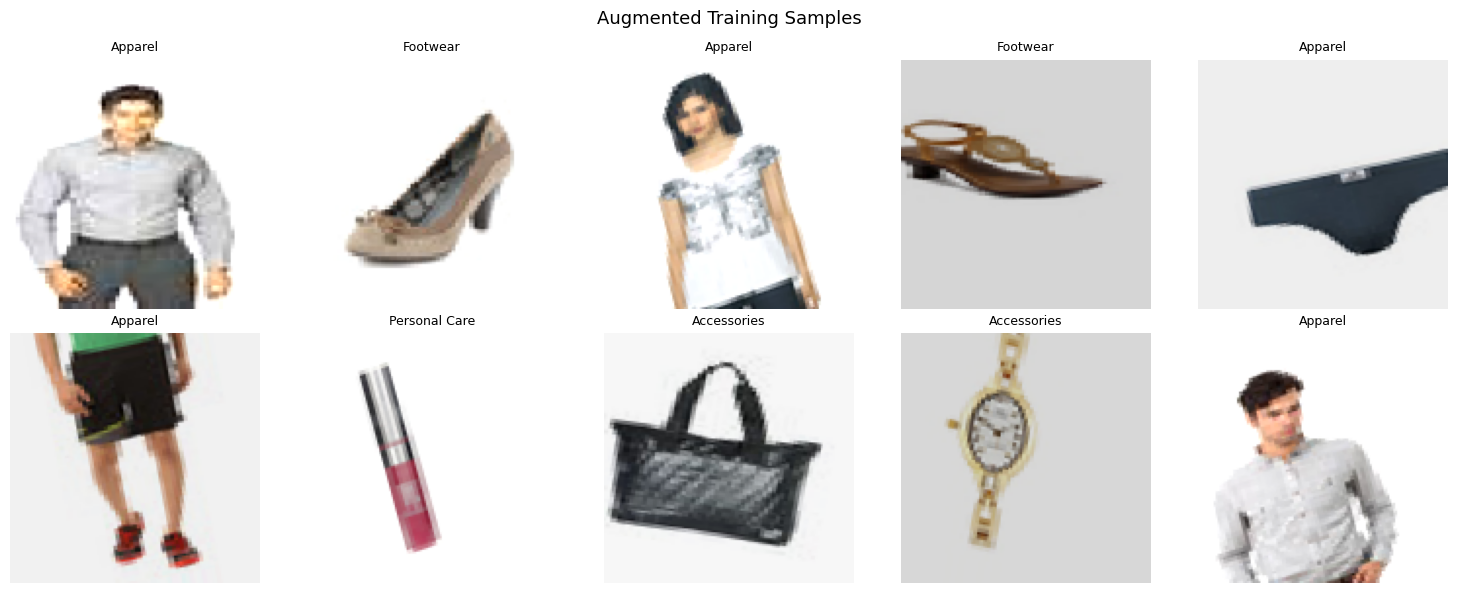

In [11]:
batch_imgs, batch_lbls = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_imgs[i]); ax.set_title(CLASS_NAMES[np.argmax(batch_lbls[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmented_samples.pdf', dpi=150)
plt.show()


---
## 🧠 Step 4: Custom CNN Model

In [12]:
def build_custom_cnn(input_shape, num_classes):
    """4-block CNN with BatchNorm, GlobalAveragePooling, and L2 regularisation."""
    m = models.Sequential(name='Custom_CNN')

    m.add(keras.Input(shape=input_shape))
    for filters, drop in [(32,0.25),(64,0.25),(128,0.30),(256,0.30)]:
        m.add(layers.Conv2D(filters,(3,3),padding='same'))
        m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
        if filters < 256:
            m.add(layers.Conv2D(filters,(3,3),padding='same'))
            m.add(layers.BatchNormalization()); m.add(layers.Activation('relu'))
        m.add(layers.MaxPooling2D(2,2)); m.add(layers.Dropout(drop))
    m.add(layers.GlobalAveragePooling2D())
    m.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    m.add(layers.Dropout(0.50))
    m.add(layers.Dense(num_classes, activation='softmax'))
    return m

cnn_model = build_custom_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()


I0000 00:00:1783501426.188003      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 652,069 (2.49 MB)

 Trainable params: 650,661 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
cnn_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

cnn_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_cnn.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
        min_lr=1e-6, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1)
]


In [14]:
start_time  = time.time()
cnn_history = cnn_model.fit(
    train_gen, epochs=EPOCHS_CNN,
    validation_data=val_gen, callbacks=cnn_callbacks, verbose=1)
cnn_time    = time.time() - start_time
print(f"Custom CNN training time: {cnn_time:.1f}s")

Epoch 1/30


I0000 00:00:1783501433.804169      69 service.cc:152] XLA service 0x79fd30022dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783501433.804250      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1783501434.920746      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/972 ━━━━━━━━━━━━━━━━━━━━ 4:14:53 16s/step - accuracy: 0.3438 - loss: 1.9267

I0000 00:00:1783501444.279480      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.7099 - loss: 0.7476
Epoch 1: val_accuracy improved from None to 0.64425, saving model to /kaggle/working/outputs/best_cnn.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_cnn.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 418s 415ms/step - accuracy: 0.7761 - loss: 0.6043 - val_accuracy: 0.6443 - val_loss: 0.8237 - learning_rate: 0.0010
Epoch 2/30
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8591 - loss: 0.4237
Epoch 2: val_accuracy improved from 0.64425 to 0.81147, saving model to /kaggle/working/outputs/best_cnn.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_cnn.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 194s 199ms/step - accuracy: 0.8694 - loss: 0.4001 - val_accuracy: 0.8115 - val_loss: 0.5278 - learning_rate: 0.0010
Epoch 3/30
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.8965 - loss: 0.3389
Epoch 3: val_accuracy did not improve from 0.81147
972/972 ━━━━━━━━━━━━━━━━━━━━ 187s 192ms

---
## 📈 Step 5: Training Curves

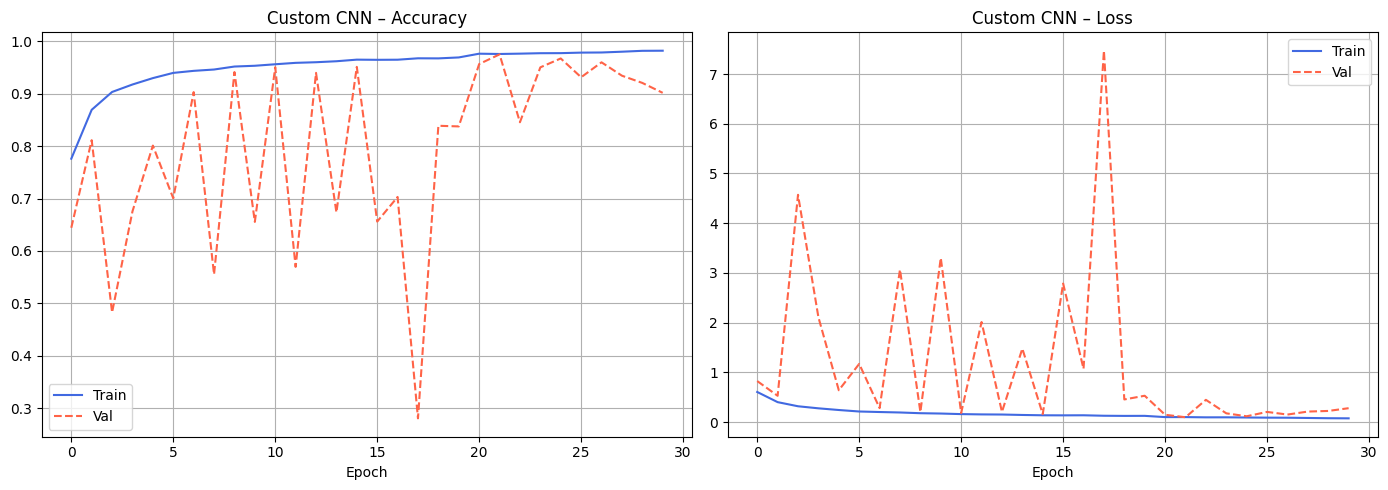

In [15]:
def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],     label='Train', color='royalblue')
    ax1.plot(history.history['val_accuracy'], label='Val',   color='tomato', ls='--')
    ax1.set_title(f'{title} – Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(0.3)
    ax2.plot(history.history['loss'],     label='Train', color='royalblue')
    ax2.plot(history.history['val_loss'], label='Val',   color='tomato', ls='--')
    ax2.set_title(f'{title} – Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()

plot_history(cnn_history, 'Custom CNN', OUTPUT_DIR / 'cnn_curves.pdf')


---
## 📊 Step 6: Evaluate Custom CNN

209/209 ━━━━━━━━━━━━━━━━━━━━ 49s 232ms/step

  Custom_CNN – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9527    0.9628    0.9577      1694
      Apparel     0.9915    0.9838    0.9876      3210
     Footwear     0.9857    0.9935    0.9896      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9299    0.9583    0.9439       360

     accuracy                         0.9769      6663
    macro avg     0.7720    0.7797    0.7758      6663
 weighted avg     0.9749    0.9769    0.9759      6663



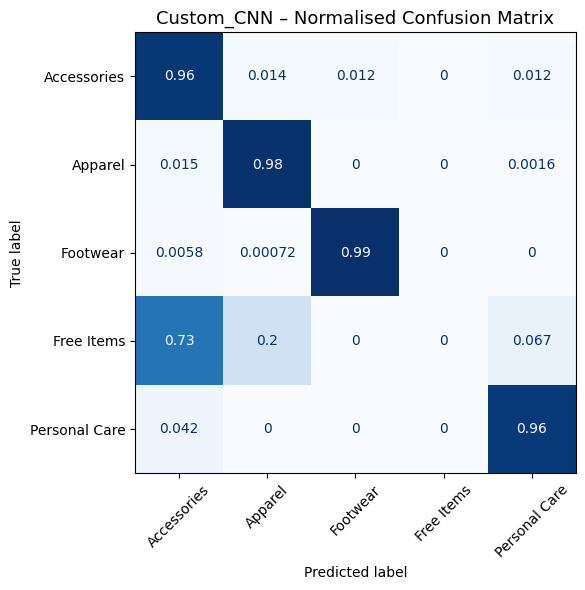

Accuracy=0.9769  Precision=0.7720  Recall=0.7797  F1=0.7758


In [16]:
def evaluate_model(model, test_gen, class_names, model_name, output_dir):
    """Predict on test set, print classification report, plot confusion matrix."""
    test_gen.reset()
    y_prob = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_gen.classes

    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{'='*55}\n  {model_name} – Classification Report\n{'='*55}")
    print(report)
    pd.DataFrame(
        classification_report(y_true, y_pred, target_names=class_names,
                              digits=4, output_dict=True)
    ).T.round(4).to_csv(output_dir / f'{model_name}_report.csv')

    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names)-2)))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{model_name} – Normalised Confusion Matrix', fontsize=13)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_confusion_matrix.pdf', dpi=150, bbox_inches='tight')
    plt.show()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    return dict(accuracy=acc, precision=prec, recall=rec, macro_f1=f1,
                y_prob=y_prob, y_pred=y_pred, y_true=y_true)

cnn_results = evaluate_model(cnn_model, test_gen, CLASS_NAMES, 'Custom_CNN', OUTPUT_DIR)


---
## 🔁 Step 7: Transfer Learning – MobileNetV2

In [17]:
def build_transfer_model(base_fn, preprocess_fn, input_shape, num_classes, name='TL'):
    """Transfer learning model: frozen ImageNet base + custom dense head.
    NOTE: preprocess_fn is applied inside the model, so generators must NOT rescale."""    
    base = base_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    inp = keras.Input(shape=input_shape)
    x   = preprocess_fn(inp)
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.Dropout(0.50)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inp, out, name=name)

mobilenet_model = build_transfer_model(
    MobileNetV2, preprocess_input, INPUT_SHAPE, NUM_CLASSES, name='MobileNetV2')
mobilenet_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9273 - loss: 0.2868
Epoch 1: val_accuracy improved from None to 0.96953, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 231s 224ms/step - accuracy: 0.9532 - loss: 0.2015 - val_accuracy: 0.9695 - val_loss: 0.1454 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9676 - loss: 0.1565
Epoch 2: val_accuracy improved from 0.96953 to 0.97523, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 196s 201ms/step - accuracy: 0.9696 - loss: 0.1522 - val_accuracy: 0.9752 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9733 - loss: 0.1390
Epoch 3: val_accuracy improved from 0.97523 to 0.98034,

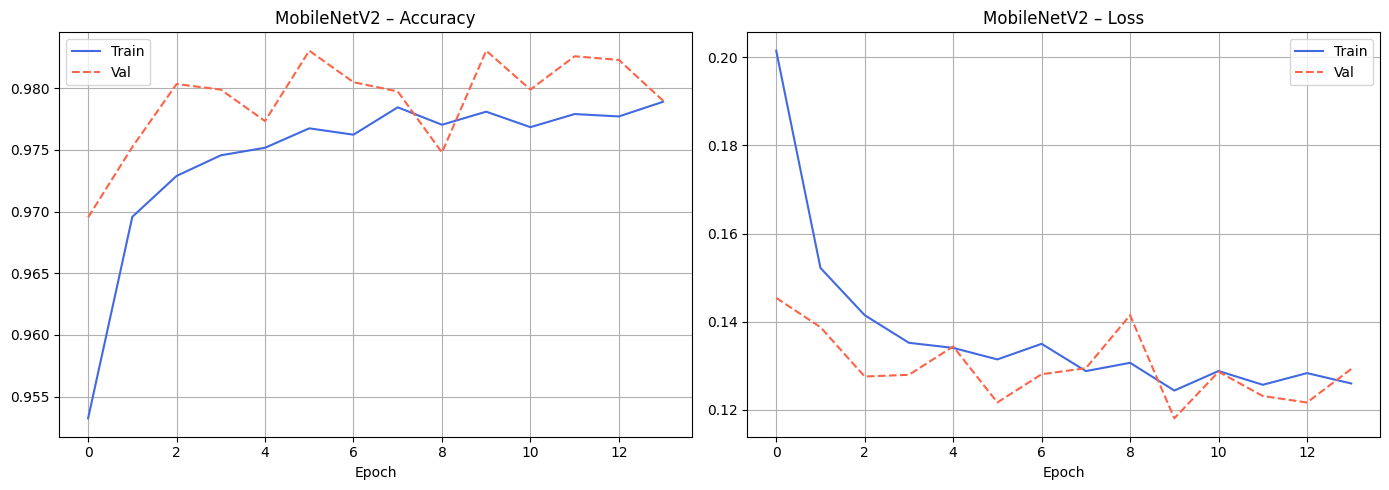

In [18]:
# ── Phase 1: Feature Extraction (base frozen) ─────────────────────────────────
mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

mn_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_mobilenet.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1)
]

start_time        = time.time()
mobilenet_history = mobilenet_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen, callbacks=mn_callbacks, verbose=1)
mobilenet_time    = time.time() - start_time
print(f"MobileNetV2 Phase 1 time: {mobilenet_time:.1f}s")
plot_history(mobilenet_history, 'MobileNetV2', OUTPUT_DIR/'mobilenet_curves.pdf')


Epoch 1/10


2026-07-08 11:28:53.077092: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 11:28:53.273697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


569/972 ━━━━━━━━━━━━━━━━━━━━ 1:10 175ms/step - accuracy: 0.9324 - loss: 0.2666

2026-07-08 11:30:39.932826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-08 11:30:40.131324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9402 - loss: 0.2431
Epoch 1: val_accuracy improved from None to 0.98034, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 219s 209ms/step - accuracy: 0.9546 - loss: 0.1989 - val_accuracy: 0.9803 - val_loss: 0.1331 - learning_rate: 1.0000e-05
Epoch 2/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9695 - loss: 0.1520
Epoch 2: val_accuracy improved from 0.98034 to 0.98109, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 192s 197ms/step - accuracy: 0.9707 - loss: 0.1482 - val_accuracy: 0.9811 - val_loss: 0.1277 - learning_rate: 1.0000e-05
Epoch 3/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9744 - loss: 0.1353
Epoch 3: val_accuracy improved from 0.98109 to 0.98124, sa

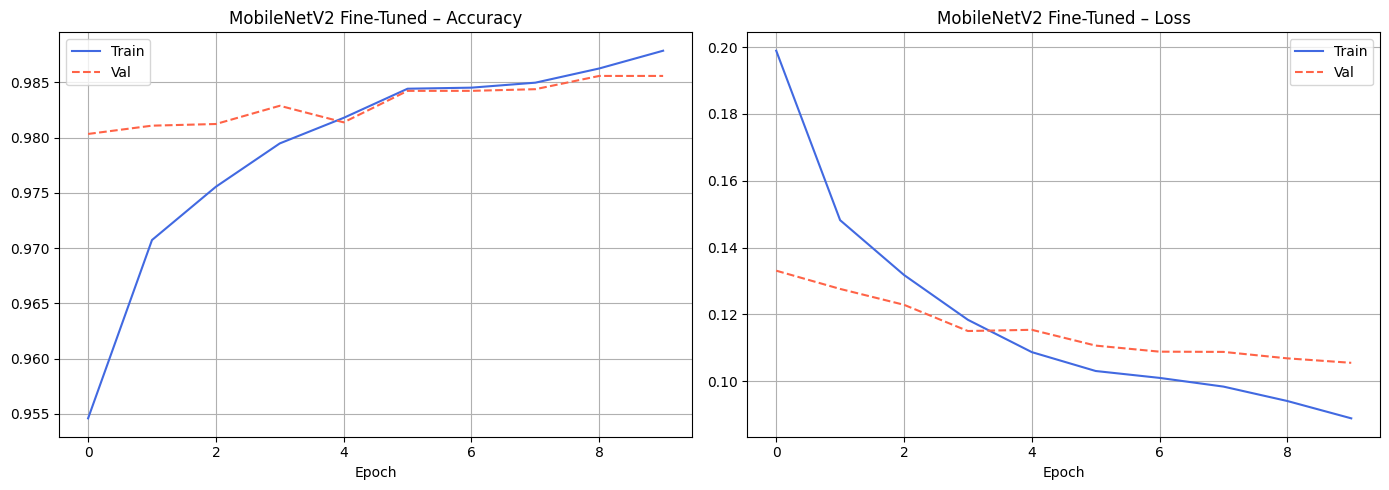

In [19]:
# ── Phase 2: Fine-Tuning (unfreeze top 30 layers of base) ────────────────────
# Locate the MobileNetV2 base layer dynamically (name varies with input size)
mn_base = next(l for l in mobilenet_model.layers if l.name.startswith('mobilenetv2'))
mn_base.trainable = True
for layer in mn_base.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy', metrics=['accuracy'])

mn_ft_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_mobilenet.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1)
]

finetune_history = mobilenet_model.fit(
    tl_train_gen, epochs=10,
    validation_data=tl_val_gen, callbacks=mn_ft_callbacks, verbose=1)
plot_history(finetune_history, 'MobileNetV2 Fine-Tuned',
             OUTPUT_DIR/'mobilenet_finetune_curves.pdf')


209/209 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step

  MobileNetV2 – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9698    0.9858    0.9778      1694
      Apparel     0.9938    0.9947    0.9942      3210
     Footwear     0.9985    0.9906    0.9946      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9746    0.9611    0.9678       360

     accuracy                         0.9875      6663
    macro avg     0.7874    0.7865    0.7869      6663
 weighted avg     0.9854    0.9875    0.9864      6663



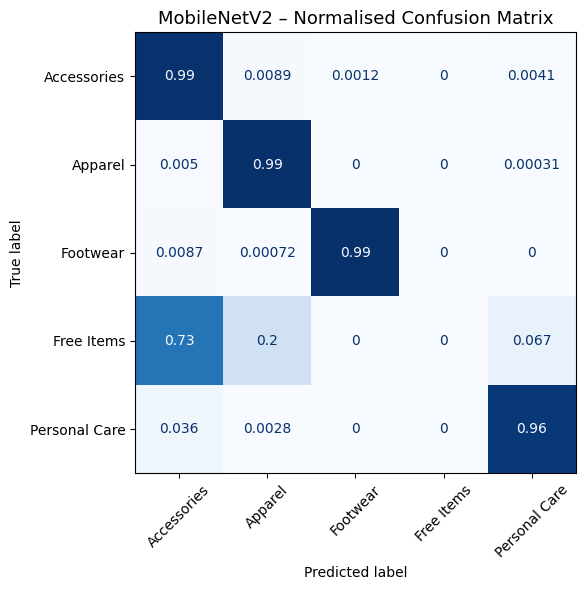

Accuracy=0.9875  Precision=0.7874  Recall=0.7865  F1=0.7869


In [20]:
mobilenet_results = evaluate_model(
    mobilenet_model, tl_test_gen, CLASS_NAMES, 'MobileNetV2', OUTPUT_DIR)


---
## 🔁 Step 8: Transfer Learning – ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 128, 128)  │          0 │ input_layer_4[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 128, 128,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 4, 4,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 5)         │      1,285 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9217 - loss: 0.3415
Epoch 1: val_accuracy improved from None to 0.96998, saving model to /kaggle/working/outputs/best_resnet50.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_resnet50.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 216s 211ms/step - accuracy: 0.9475 - loss: 0.2334 - val_accuracy: 0.9700 - val_loss: 0.1521 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.9670 - loss: 0.1655
Epoch 2: val_accuracy improved from 0.96998 to 0.97838, saving model to /kaggle/working/outputs/best_resnet50.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_resnet50.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 198s 204ms/step - accuracy: 0.9647 - loss: 0.1719 - val_accuracy: 0.9784 - val_loss: 0.1309 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9653 - loss: 0.1662
Epoch 3: val_accuracy did not improve from 0.97838
972/972 

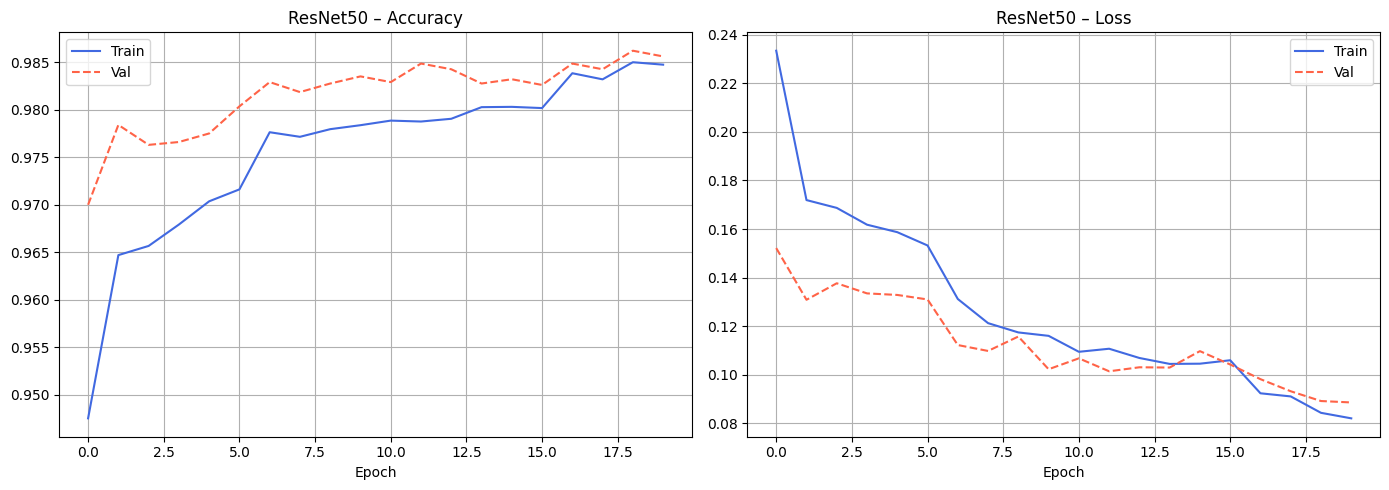

209/209 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step

  ResNet50 – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9816    0.9770    0.9793      1694
      Apparel     0.9913    0.9981    0.9947      3210
     Footwear     0.9957    0.9957    0.9957      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9695    0.9722    0.9709       360

     accuracy                         0.9886      6663
    macro avg     0.7876    0.7886    0.7881      6663
 weighted avg     0.9864    0.9886    0.9875      6663



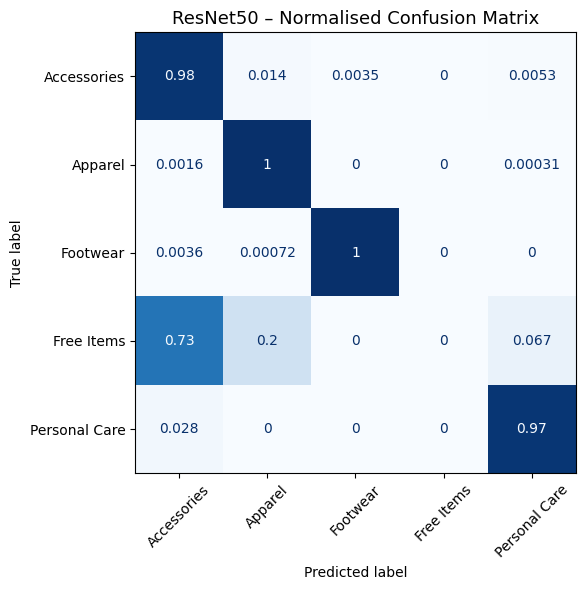

Accuracy=0.9886  Precision=0.7876  Recall=0.7886  F1=0.7881


In [21]:
resnet_model = build_transfer_model(
    ResNet50, resnet_preprocess, INPUT_SHAPE, NUM_CLASSES, name='ResNet50')
resnet_model.summary()

resnet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy'])

# Separate callbacks so ResNet50 checkpoint does not overwrite MobileNetV2
rn_callbacks = [
    callbacks.ModelCheckpoint(str(OUTPUT_DIR/'best_resnet50.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1)
]

start_time     = time.time()
resnet_history = resnet_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen, callbacks=rn_callbacks, verbose=1)
resnet_time    = time.time() - start_time
print(f"ResNet50 training time: {resnet_time:.1f}s")
plot_history(resnet_history, 'ResNet50', OUTPUT_DIR/'resnet_curves.pdf')

resnet_results = evaluate_model(
    resnet_model, tl_test_gen, CLASS_NAMES, 'ResNet50', OUTPUT_DIR)


---
## 📊 Step 9: Model Comparison Table

In [22]:
comparison = pd.DataFrame({
    'Model':         ['Custom CNN', 'MobileNetV2', 'ResNet50'],
    'Accuracy':      [cnn_results['accuracy'],      mobilenet_results['accuracy'],      resnet_results['accuracy']],
    'Precision':     [cnn_results['precision'],     mobilenet_results['precision'],     resnet_results['precision']],
    'Recall':        [cnn_results['recall'],        mobilenet_results['recall'],        resnet_results['recall']],
    'Macro F1':      [cnn_results['macro_f1'],      mobilenet_results['macro_f1'],      resnet_results['macro_f1']],
    'Training Time': [f"{cnn_time:.1f}s",           f"{mobilenet_time:.1f}s",           f"{resnet_time:.1f}s"],
    'Parameters':    [cnn_model.count_params(),     mobilenet_model.count_params(),     resnet_model.count_params()],
}).round({'Accuracy':4,'Precision':4,'Recall':4,'Macro F1':4})

comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
comparison


,Model,Accuracy,Precision,Recall,Macro F1,Training Time,Parameters
0,Custom CNN,0.9769,0.7720,0.7797,0.7758,5868.6s,652069
1,MobileNetV2,0.9875,0.7874,0.7865,0.7869,2746.6s,2587205
2,ResNet50,0.9886,0.7876,0.7886,0.7881,3853.2s,24113541


## 📐 Step 10: Statistical Reliability (Confidence Intervals & McNemar Test)

We attach 95% **Wilson confidence intervals** to each model's test accuracy and run **McNemar's test** to check whether the accuracy gap between the two best models is statistically significant. Predictions were produced with `shuffle=False` on the same `test_df`, so the models are aligned image-by-image.

In [23]:
# ============================================================
# Statistical reliability:  95% Wilson CIs  +  McNemar's test
# Reuses the predictions already returned by evaluate_model().
# Test generators use shuffle=False on the same test_df, so the
# three models are paired image-by-image with the same y_true.
# ============================================================
import math
import numpy as np
import pandas as pd

try:
    from scipy.stats import chi2
    try:
        from scipy.stats import binomtest
        _binom_p = lambda k, m: binomtest(k, m, 0.5).pvalue
    except Exception:                       # older scipy
        from scipy.stats import binom_test
        _binom_p = lambda k, m: binom_test(k, m, 0.5)
    _chi_sf = lambda s: chi2.sf(s, 1)
except Exception:                           # no scipy at all
    _binom_p = lambda k, m: 1.0
    _chi_sf  = lambda s: math.erfc(math.sqrt(s / 2.0))

def wilson_ci(correct, n, z=1.96):
    p = correct / n
    d = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / d
    half   = (z / d) * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return centre - half, centre + half

results = {'Custom CNN':  cnn_results,
           'MobileNetV2': mobilenet_results,
           'ResNet50':    resnet_results}

y_true = resnet_results['y_true']
n = len(y_true)

rows = []
for name, r in results.items():
    correct = int((r['y_pred'] == r['y_true']).sum())
    lo, hi  = wilson_ci(correct, n)
    rows.append({'Model': name, 'Accuracy': round(correct / n, 4),
                 'Correct': correct, 'N': n,
                 '95% CI low': round(lo, 4), '95% CI high': round(hi, 4),
                 '+/- (pp)': round((hi - lo) / 2 * 100, 2)})
ci_df = pd.DataFrame(rows)
print("95% Wilson confidence intervals for test accuracy:\n")
print(ci_df.to_string(index=False))
ci_df.to_csv(OUTPUT_DIR / 'statistical_accuracy_CIs.csv', index=False)

# ---- McNemar's test: ResNet50 vs MobileNetV2 (paired) ----
res_ok = (resnet_results['y_pred']    == y_true)
mob_ok = (mobilenet_results['y_pred'] == y_true)
b = int(np.sum( res_ok & ~mob_ok))          # ResNet right, MobileNet wrong
c = int(np.sum(~res_ok &  mob_ok))          # ResNet wrong, MobileNet right

if (b + c) == 0:
    p_value, test_used = 1.0, "no discordant pairs"
elif (b + c) < 25:
    p_value, test_used = _binom_p(min(b, c), b + c), "exact binomial"
else:
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_value, test_used = _chi_sf(stat), "chi-square (continuity corrected)"

verdict = ("NO statistically significant difference"
           if p_value > 0.05 else "a statistically significant difference")

print("\nMcNemar's test  -  ResNet50 vs MobileNetV2")
print(f"  b (ResNet right, MobileNet wrong) = {b}")
print(f"  c (ResNet wrong, MobileNet right) = {c}")
print(f"  test = {test_used},  p-value = {p_value:.4f}")
print(f"  => {verdict} at alpha = 0.05")

pd.DataFrame([{'comparison': 'ResNet50 vs MobileNetV2', 'b': b, 'c': c,
               'test': test_used, 'p_value': round(p_value, 4),
               'verdict': verdict}]).to_csv(
    OUTPUT_DIR / 'statistical_mcnemar.csv', index=False)


95% Wilson confidence intervals for test accuracy:

      Model  Accuracy  Correct    N  95% CI low  95% CI high  +/- (pp)
 Custom CNN    0.9769     6509 6663      0.9730       0.9802      0.36
MobileNetV2    0.9875     6580 6663      0.9846       0.9899      0.27
   ResNet50    0.9886     6587 6663      0.9857       0.9909      0.26

McNemar's test  -  ResNet50 vs MobileNetV2
  b (ResNet right, MobileNet wrong) = 41
  c (ResNet wrong, MobileNet right) = 34
  test = chi-square (continuity corrected),  p-value = 0.4884
  => NO statistically significant difference at alpha = 0.05


## 🌫️ Step 11: Robustness Testing (Image Degradation)

Evaluate every trained model on corrupted versions of the test set (blur, noise, brightness, occlusion, JPEG compression) at increasing severity, and plot accuracy vs severity. Severity 0 = clean.

Robustness evaluation on 2000 test images
  Blur done
  Noise done
  Brightness done
  Occlusion done
  JPEG done

Accuracy vs severity:
Model                Custom CNN  MobileNetV2  ResNet50
Corruption Severity                                   
Blur       0             0.9755       0.9885    0.9905
           1             0.9695       0.9875    0.9900
           2             0.9580       0.9835    0.9855
           3             0.9175       0.9720    0.9805
Brightness 0             0.9755       0.9885    0.9905
           1             0.9770       0.9870    0.9870
           2             0.8365       0.9850    0.9830
           3             0.8990       0.9640    0.9535
JPEG       0             0.9760       0.9885    0.9900
           1             0.9685       0.9860    0.9900
           2             0.9665       0.9845    0.9870
           3             0.9395       0.9790    0.9815
Noise      0             0.9755       0.9885    0.9905
           1             0.5485       

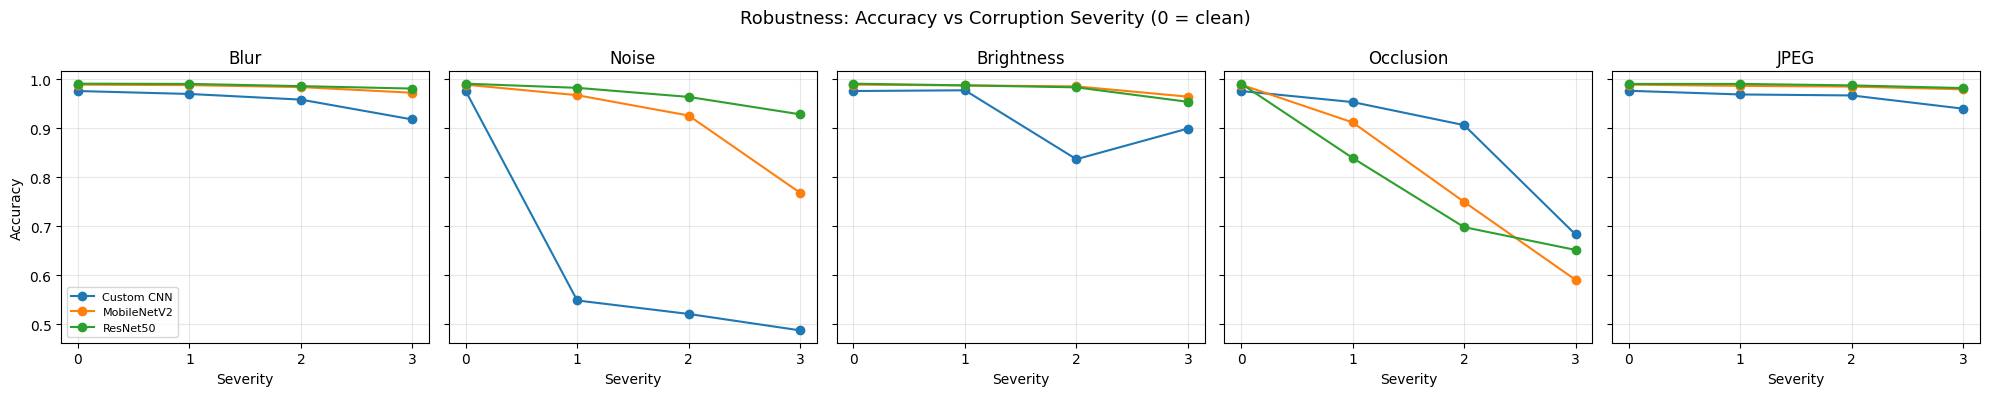

In [24]:
# ============================================================
# Robustness Testing: accuracy under image degradation
# Corrupts the test images and re-evaluates each trained model.
# ============================================================
import cv2, os, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# (optional) subsample the test set for speed; set N_ROBUST = None for ALL images
N_ROBUST = 2000
rob_df = test_df.reset_index(drop=True)
if N_ROBUST and N_ROBUST < len(rob_df):
    rob_df = rob_df.sample(N_ROBUST, random_state=SEED).reset_index(drop=True)

X_test = np.zeros((len(rob_df), IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
for i, p in enumerate(rob_df['image_path'].values):
    X_test[i] = img_to_array(load_img(p, target_size=IMG_SIZE)).astype(np.uint8)
y_test = rob_df['label'].values
print(f"Robustness evaluation on {len(rob_df)} test images")

# --- corruption functions on a uint8 HxWx3 image; severity s in 0..3 (0 = clean) ---
def c_blur(img, s):
    k = [1, 3, 5, 7][s];  return cv2.GaussianBlur(img, (k, k), 0) if k > 1 else img
def c_noise(img, s):
    sd = [0, 10, 20, 35][s]
    return np.clip(img + np.random.normal(0, sd, img.shape), 0, 255).astype(np.uint8)
def c_bright(img, s):
    f = [1.0, 0.7, 0.5, 1.4][s];  return np.clip(img * f, 0, 255).astype(np.uint8)
def c_occlude(img, s):
    frac = [0.0, 0.2, 0.35, 0.5][s]
    if frac == 0: return img
    h, w = img.shape[:2]; ph, pw = int(h*frac), int(w*frac)
    y0, x0 = (h-ph)//2, (w-pw)//2
    im = img.copy(); im[y0:y0+ph, x0:x0+pw] = 0; return im
def c_jpeg(img, s):
    q = [100, 50, 25, 10][s]
    _, enc = cv2.imencode('.jpg', img, [int(cv2.IMWRITE_JPEG_QUALITY), q])
    return cv2.imdecode(enc, 1)

CORRUPTIONS = {'Blur': c_blur, 'Noise': c_noise, 'Brightness': c_bright,
               'Occlusion': c_occlude, 'JPEG': c_jpeg}
SEVERITIES = [0, 1, 2, 3]

# per-model preprocessing: Custom CNN expects [0,1]; TL models preprocess inside the graph
MODELS = {'Custom CNN': (cnn_model, True),
          'MobileNetV2': (mobilenet_model, False),
          'ResNet50':    (resnet_model, False)}

def acc_on(Xc, model, rescale):
    Xf = Xc.astype('float32')
    if rescale: Xf = Xf / 255.0
    yp = model.predict(Xf, batch_size=BATCH_SIZE, verbose=0).argmax(1)
    return float((yp == y_test).mean())

rows = []
for cname, cfn in CORRUPTIONS.items():
    for s in SEVERITIES:
        Xc = np.stack([cfn(im, s) for im in X_test])
        for mname, (mdl, rs) in MODELS.items():
            rows.append({'Corruption': cname, 'Severity': s,
                         'Model': mname, 'Accuracy': round(acc_on(Xc, mdl, rs), 4)})
    print(f"  {cname} done")

rob = pd.DataFrame(rows)
rob.to_csv(OUTPUT_DIR / 'robustness_results.csv', index=False)
print("\nAccuracy vs severity:")
print(rob.pivot_table(index=['Corruption', 'Severity'], columns='Model', values='Accuracy'))

fig, axes = plt.subplots(1, len(CORRUPTIONS), figsize=(20, 4), sharey=True)
for ax, cname in zip(axes, CORRUPTIONS):
    sub = rob[rob.Corruption == cname]
    for mname in MODELS:
        d = sub[sub.Model == mname]
        ax.plot(d.Severity, d.Accuracy, marker='o', label=mname)
    ax.set_title(cname); ax.set_xlabel('Severity'); ax.set_xticks(SEVERITIES); ax.grid(alpha=.3)
axes[0].set_ylabel('Accuracy'); axes[0].legend(fontsize=8)
plt.suptitle('Robustness: Accuracy vs Corruption Severity (0 = clean)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'robustness_curves.pdf', bbox_inches='tight')
plt.show()

## 🌍 Step 12: External Validation

Test a trained model on an **independent, labelled** image set from a **different source** than the original dataset. Point `EXTERNAL_DIR` at a folder with one subfolder per class (`Accessories/`, `Apparel/`, `Footwear/`, `Free Items/`, `Personal Care/`).

In [25]:
# ============================================================
# Build an EXTERNAL_TEST folder (5 category subfolders) for
# External Validation, from the Farfetch dataset (crawlfeeds):
#   images/images/<itemid>_<n>.jpg  +  farfetch_..._crawlfeeds.json
# Farfetch is a DIFFERENT retailer than your Myntra training data,
# so it counts as genuinely external.
#
# USE in a Kaggle notebook (after adding the dataset as input):
#   1. Run this cell. Read the printed diagnostics (JSON keys,
#      sample breadcrumbs, per-class counts).
#   2. If a class is empty, add the wording you see to KEYWORDS.
#   3. Point Step 12's EXTERNAL_DIR at /kaggle/working/external_test
# ============================================================
import os, glob, json, shutil, re
import pandas as pd
from pathlib import Path

PER_CLASS = 40
OUT_DIR   = Path('/kaggle/working/external_test')
CLASSES   = ['Accessories', 'Apparel', 'Footwear', 'Personal Care', 'Free Items']

KEYWORDS = [
    ('Personal Care', ['beauty','fragrance','perfume','cologne','skincare','skin care',
                        'grooming','cosmetic','make-up','makeup','lipstick','lotion']),
    ('Footwear',      ['shoe','sneaker','trainer','boot','sandal','heel','loafer','pump',
                       'espadrille','mule','ballerina','slipper','brogue','derby']),
    ('Accessories',   ['bag','belt','watch','sunglass','jewell','jewel','necklace','bracelet',
                       'earring',' ring','scarf','hat','glove','wallet','purse','clutch',
                       'backpack','tote','tie','beanie','keyring','cardholder','pouch']),
    ('Apparel',       ['clothing','dress','shirt','t-shirt','tee','trouser','pant','jean',
                       'jacket','coat','knit','sweater','sweatshirt','hoodie','top','blouse',
                       'skirt','shorts','suit','blazer','cardigan','jumper','legging','gown',
                       'parka','denim','polo']),
]

# ---- locate the JSON metadata anywhere under /kaggle/input ----
cands = glob.glob('/kaggle/input/**/farfetch_*crawlfeeds*.json', recursive=True) \
     or glob.glob('/kaggle/input/**/*farfetch*.json', recursive=True) \
     or glob.glob('/kaggle/input/**/images-extracted-from-fashion-website/**/*.json', recursive=True)
assert cands, "Could not find the Farfetch JSON under /kaggle/input. Check the dataset is added."
JSON_PATH = cands[0]
DATA_ROOT = Path(JSON_PATH).parent
print("JSON :", JSON_PATH)
print("ROOT :", DATA_ROOT)

# ---- load JSON robustly (list, dict-wrapped, or json-lines) ----
try:
    raw = json.load(open(JSON_PATH))
    if isinstance(raw, dict):
        raw = next((v for v in raw.values() if isinstance(v, list)), [raw])
    df = pd.DataFrame(raw)
except Exception:
    df = pd.read_json(JSON_PATH, lines=True)
print("Records:", len(df), "| Columns:", list(df.columns))

# ---- text field for classifying ----
text_cols = [c for c in ['breadcrumbs','category','categories','title','name',
                         'product_name','details','description'] if c in df.columns]
print("Text columns used:", text_cols)
df['_text'] = df[text_cols].astype(str).agg(' | '.join, axis=1).str.lower()
print("Sample text values:")
for v in df['_text'].head(3): print("   ", v[:120])

def classify(t):
    for cls, kws in KEYWORDS:
        if any(k in t for k in kws): return cls
    return None
df['_class'] = df['_text'].apply(classify)
print("\nProducts per class (from metadata):")
print(df['_class'].value_counts(dropna=False))

# ---- index every image by full basename AND by item-id prefix ----
imgs = []
for ext in ('*.jpg','*.jpeg','*.png','*.webp'):
    imgs += glob.glob(str(DATA_ROOT / '**' / ext), recursive=True)
by_name = {os.path.basename(p): p for p in imgs}
by_id   = {}
for p in imgs:
    key = re.split(r'[_\.]', os.path.basename(p))[0]      # '10851775_0.jpg' -> '10851775'
    by_id.setdefault(key, []).append(p)
print(f"\nImage files found: {len(imgs)}")

id_cols  = [c for c in ['item_id','sku','uniq_id','id','product_id'] if c in df.columns]
img_cols = [c for c in ['image_file','image','filename','file','images'] if c in df.columns]

def find_image(row):
    # 1) explicit image column -> match by basename
    for col in img_cols:
        val = row.get(col)
        if isinstance(val, list) and val: val = val[0]
        if isinstance(val, str) and val:
            b = os.path.basename(val.split('?')[0])
            if b in by_name: return by_name[b]
    # 2) fall back to item-id prefix
    for col in id_cols:
        key = str(row.get(col, '')).strip()
        if key in by_id: return by_id[key][0]
    return None

# ---- copy up to PER_CLASS per class ----
for c in CLASSES: (OUT_DIR / c).mkdir(parents=True, exist_ok=True)
for cls in ['Accessories', 'Apparel', 'Footwear', 'Personal Care']:
    rows = df[df['_class'] == cls].sample(frac=1, random_state=42)
    copied = 0
    for _, r in rows.iterrows():
        src = find_image(r)
        if src and os.path.exists(src):
            shutil.copy(src, OUT_DIR / cls / os.path.basename(src)); copied += 1
        if copied >= PER_CLASS: break
    print(f"  {cls:14s}: copied {copied}")

print("\nexternal_test built at:", OUT_DIR)
for c in CLASSES:
    print(f"  {c:14s}: {len(list((OUT_DIR / c).glob('*')))} images")
print("\n'Free Items' stays empty (no external retailer has it); Step 12 handles that.")

JSON : /kaggle/input/datasets/crawlfeeds/images-extracted-from-fashion-website/farfetch_fashion_dataset_images_crawlfeeds.json
ROOT : /kaggle/input/datasets/crawlfeeds/images-extracted-from-fashion-website
Records: 141 | Columns: ['url', 'title', 'brand', 'price', 'currency', 'formatted_price', 'availability', 'item_id', 'sku', 'condition', 'images', 'description', 'breadcrumbs', 'gender', 'details', 'uniq_id', 'scraped_at', 'image_file']
Text columns used: ['breadcrumbs', 'title', 'details', 'description']
Sample text values:
    women, pucci, accessories | scorci fiorentini print scarf | <div aria-labelledby="tab-0" class="ltr-cmgatk e1r2ta6c0" da
    women, shrimps, clothing | wide-collar crochet sweater  | <div aria-labelledby="tab-0" class="ltr-cmgatk e1r2ta6c0" data
    women, tory burch, clothing | logo-embroidered fine-knit jumper  | <div aria-labelledby="tab-0" class="ltr-cmgatk e1r2ta

Products per class (from metadata):
_class
Apparel          60
Accessories      46
Footwear

External images per class: {'Accessories': 40, 'Apparel': 40, 'Footwear': 34, 'Free Items': 0, 'Personal Care': 1}
Validating on 3 classes (>= 5 images): ['Accessories', 'Apparel', 'Footwear']
Skipped (too few / no images): ['Free Items', 'Personal Care']
Found 114 files belonging to 3 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

EXTERNAL-VALIDATION ACCURACY  (114 images, 3 classes): 0.4737

              precision    recall  f1-score   support

 Accessories     0.3651    0.5750    0.4466        40
     Apparel     0.6042    0.7250    0.6591        40
    Footwear     1.0000    0.0588    0.1111        34

   micro avg     0.4779    0.4737    0.4758       114
   macro avg     0.6564    0.4529    0.4056       114
weighted avg     0.6383    0.4737    0.4211       114



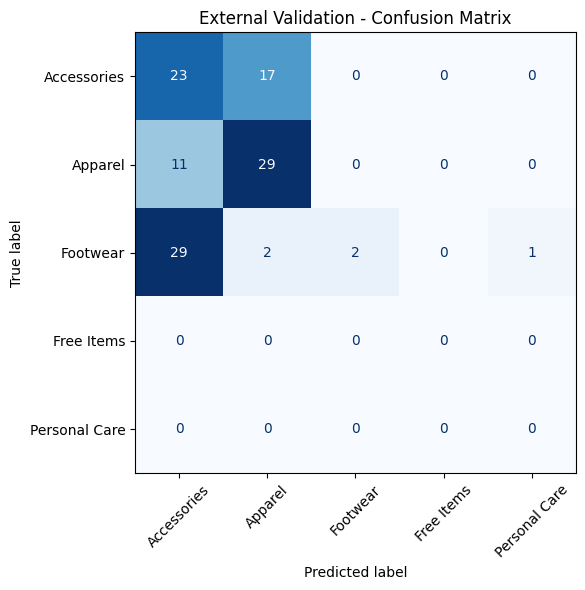

In [26]:
# ============================================================
# External Validation (auto-detects usable class folders).
# Ignores classes with too few external images, and compares by
# class NAME so the model's full 5-class output still maps correctly.
# ============================================================
import os, numpy as np, pandas as pd, tensorflow as tf
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

EXTERNAL_DIR  = '/kaggle/working/external_test'   # built by build_external_test.py
EV_MODEL      = resnet_model     # any trained model; outputs the 5 CLASS_NAMES
EV_RESCALE    = False            # True ONLY if EV_MODEL is the Custom CNN
MIN_PER_CLASS = 5                # skip classes with fewer than this many images

MODEL_CLASSES = list(CLASS_NAMES)         # full 5-class output order (training order)
_EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')

def _count_images(d):
    return sum(f.lower().endswith(_EXTS) for f in os.listdir(d)) if os.path.isdir(d) else 0

if not os.path.isdir(EXTERNAL_DIR):
    print(f"EXTERNAL_DIR not found: {EXTERNAL_DIR}")
    print("Build it first (build_external_test.py), then re-run this cell.")
else:
    counts  = {c: _count_images(os.path.join(EXTERNAL_DIR, c)) for c in MODEL_CLASSES}
    present = [c for c in MODEL_CLASSES if counts[c] >= MIN_PER_CLASS]
    print("External images per class:", counts)
    print(f"Validating on {len(present)} classes (>= {MIN_PER_CLASS} images):", present)
    skipped = [c for c in MODEL_CLASSES if c not in present]
    if skipped:
        print("Skipped (too few / no images):", skipped)

    ev_ds = tf.keras.utils.image_dataset_from_directory(
        EXTERNAL_DIR, labels='inferred', label_mode='int',
        class_names=present, image_size=IMG_SIZE,
        batch_size=BATCH_SIZE, shuffle=False)

    y_true_idx = np.concatenate([y.numpy() for _, y in ev_ds])
    y_true = np.array([present[i] for i in y_true_idx])            # true class NAMES

    def _prep(x):
        x = tf.cast(x, tf.float32)
        return x / 255.0 if EV_RESCALE else x

    prob   = EV_MODEL.predict(ev_ds.map(lambda x, y: (_prep(x), y)), verbose=1)
    y_pred = np.array([MODEL_CLASSES[i] for i in prob.argmax(1)])  # predicted NAMES (5-class space)

    acc = accuracy_score(y_true, y_pred)
    print(f"\nEXTERNAL-VALIDATION ACCURACY  ({len(y_true)} images, {len(present)} classes): {acc:.4f}\n")
    print(classification_report(y_true, y_pred, labels=present, digits=4, zero_division=0))
    pd.DataFrame(classification_report(y_true, y_pred, labels=present, digits=4,
                 zero_division=0, output_dict=True)).T.round(4).to_csv(
                 OUTPUT_DIR / 'external_validation_report.csv')

    cm = confusion_matrix(y_true, y_pred, labels=MODEL_CLASSES)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(cm, display_labels=MODEL_CLASSES).plot(
        ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    plt.title('External Validation - Confusion Matrix')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'external_validation_confusion_matrix.pdf', bbox_inches='tight')
    plt.show()

---
## 🌡️ Step 13: Grad-CAM Visualisation

Grad-CAM highlights the image regions each model focused on when making predictions. Applied to correctly classified test images for all three models.

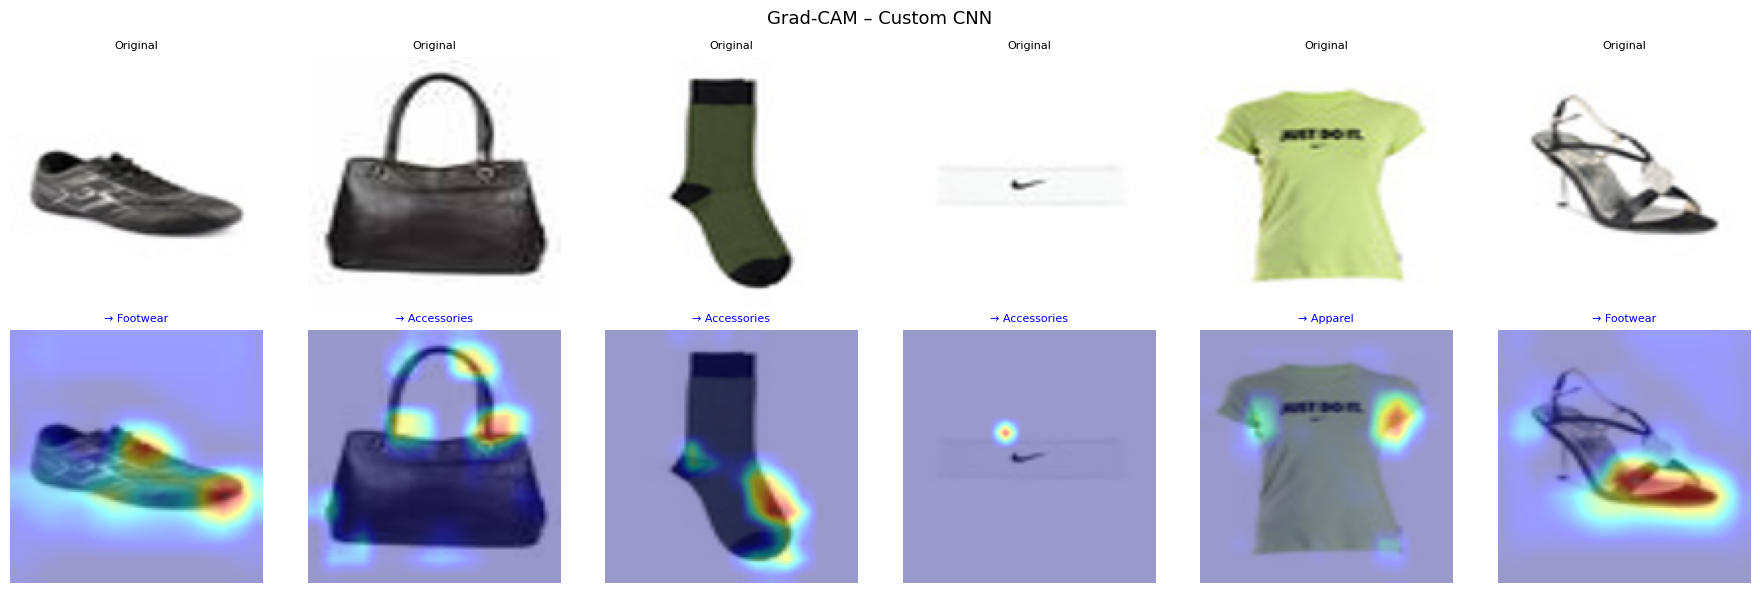

In [27]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):

    # Rebuild model graph
    inputs = tf.keras.Input(shape=model.input_shape[1:])

    x = inputs
    last_conv_output = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            last_conv_output = x

    grad_model = tf.keras.Model(
        inputs=inputs,
        outputs=[last_conv_output, x]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(
            tf.cast(img_array, tf.float32),
            training=False
        )

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index)

def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image. Returns RGB numpy array."""
    img          = cv2.imread(str(img_path))
    img          = cv2.resize(img, IMG_SIZE)
    h_resized    = cv2.resize(np.float32(heatmap), IMG_SIZE)
    h_uint8      = np.uint8(255 * h_resized)
    h_color      = cv2.applyColorMap(h_uint8, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1-alpha, h_color, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)


# ── Grad-CAM: Custom CNN ──────────────────────────────────────────────────────
# Find last Conv2D layer in the Sequential model
last_conv = [l.name for l in cnn_model.layers if isinstance(l, layers.Conv2D)][-1]

sample_paths = test_df_reset.sample(6, random_state=SEED)['image_path'].tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, path in enumerate(sample_paths):
    img_pil = Image.open(path).convert('RGB').resize(IMG_SIZE)
    # CNN expects 0-1 range (rescale=1/255 is in datagen)
    img_arr = np.expand_dims(np.array(img_pil) / 255.0, 0).astype('float32')
    heatmap, pred_idx = get_gradcam_heatmap(cnn_model, img_arr, last_conv)
    axes[0][col].imshow(img_pil);                axes[0][col].set_title('Original', fontsize=8);                axes[0][col].axis('off')
    axes[1][col].imshow(overlay_gradcam(path, heatmap))
    axes[1][col].set_title(f'→ {CLASS_NAMES[pred_idx]}', fontsize=8, color='blue')
    axes[1][col].axis('off')
plt.suptitle('Grad-CAM – Custom CNN', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## 🌡️ Grad-CAM – MobileNetV2

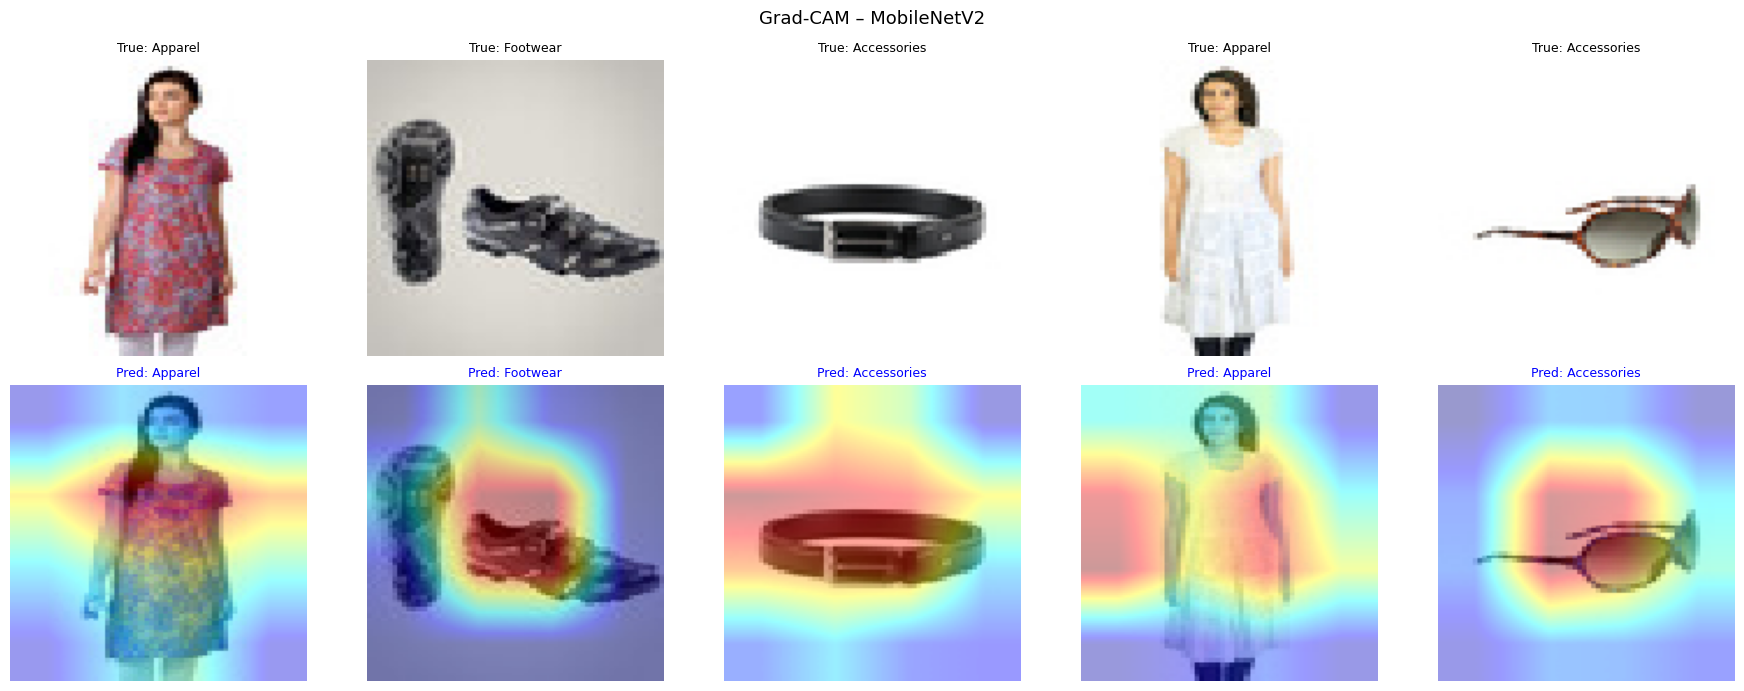

In [28]:
def get_gradcam_heatmap_mobilenet(model, img_array):

    # MobileNetV2 backbone
    base_model = model.get_layer("mobilenetv2_1.00_128")

    # Classification head
    classifier = tf.keras.Sequential(model.layers[2:])

    with tf.GradientTape() as tape:

        processed = preprocess_input(
            tf.cast(img_array, tf.float32)
        )
        
        conv_outputs = base_model(
            processed,
            training=False
        )

        tape.watch(conv_outputs)

        # Forward through classifier head
        predictions = classifier(
            conv_outputs,
            training=False
        )

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(
        conv_outputs[0] * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy(), int(pred_index)

# Use tl_test_gen — images in 0-255 range, preprocess is inside the model
images_mn, labels_mn = next(tl_test_gen)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(5):
    img_arr = np.expand_dims(images_mn[i], 0).astype('float32')  # 0-255, handled inside model
    heatmap, pred_idx = get_gradcam_heatmap_mobilenet(
    mobilenet_model,
    img_arr
    )

    disp = images_mn[i].copy()
    if disp.max() > 1.0:
        disp = disp.astype(np.uint8)  # keep 0-255 for overlay

    h_r   = cv2.resize(np.uint8(255 * heatmap), (disp.shape[1], disp.shape[0]))
    over  = cv2.addWeighted(disp, 0.6, cv2.applyColorMap(h_r, cv2.COLORMAP_JET), 0.4, 0)

    axes[0][i].imshow(disp.astype(np.uint8)); axes[0][i].axis('off')
    axes[0][i].set_title(f"True: {CLASS_NAMES[np.argmax(labels_mn[i])]}", fontsize=9)
    axes[1][i].imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB)); axes[1][i].axis('off')
    axes[1][i].set_title(f"Pred: {CLASS_NAMES[pred_idx]}", fontsize=9, color='blue')

plt.suptitle('Grad-CAM – MobileNetV2', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mobilenet_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()

---
## 🌡️ Grad-CAM – ResNet50

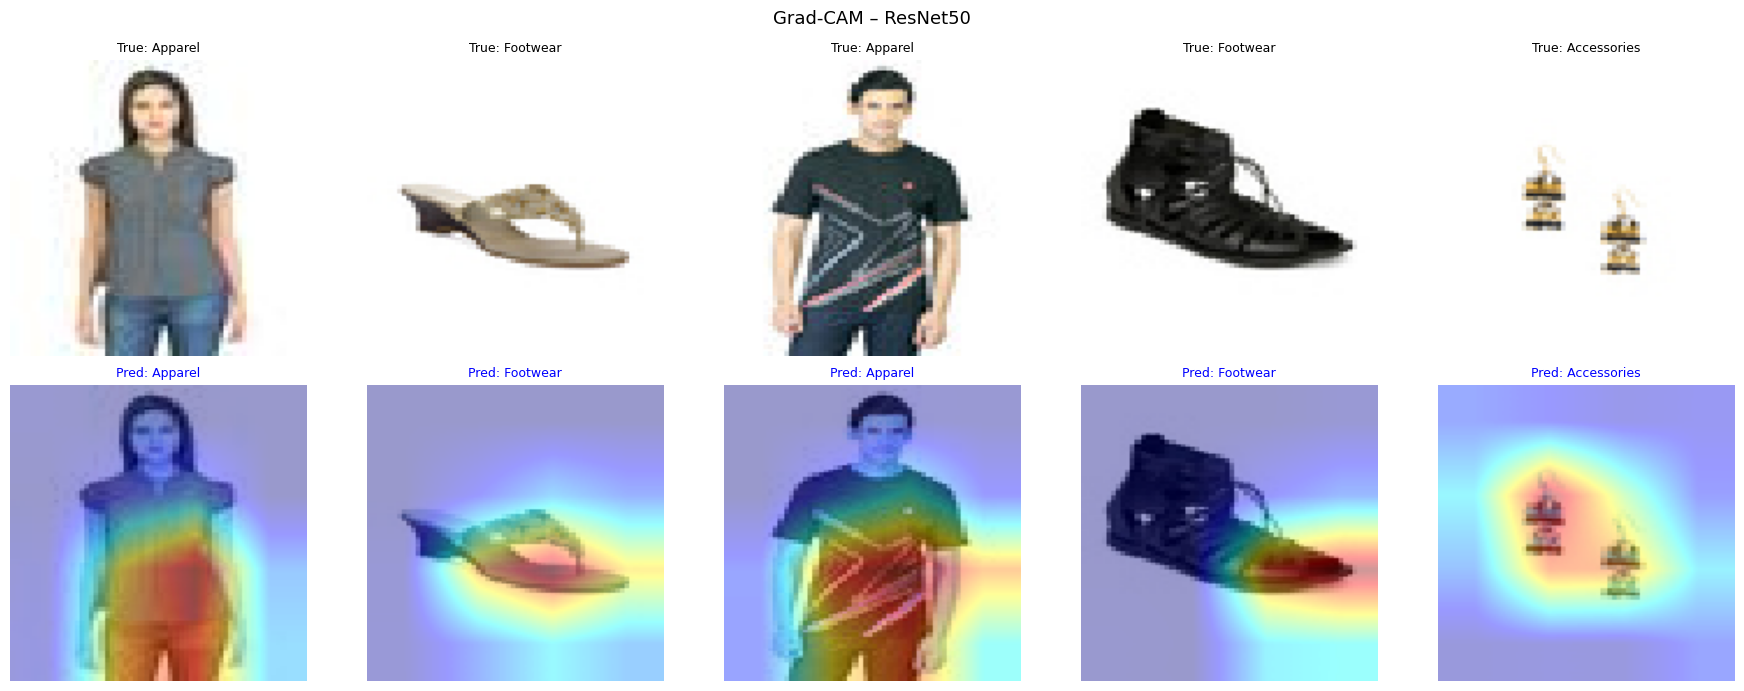

In [29]:
def get_gradcam_heatmap_resnet(model, img_array):

    base_model = model.layers[1]   # ResNet50 backbone

    # Apply ResNet preprocessing
    processed = tf.keras.applications.resnet50.preprocess_input(
        tf.cast(img_array, tf.float32)
    )

    # Forward through backbone
    conv_outputs = base_model(processed, training=False)

    # Classification head
    x = conv_outputs
    for layer in model.layers[2:]:
        x = layer(x, training=False)

    predictions = x

    pred_index = tf.argmax(predictions[0])

    with tf.GradientTape() as tape:

        conv_outputs = base_model(processed, training=False)
        tape.watch(conv_outputs)

        x = conv_outputs
        for layer in model.layers[2:]:
            x = layer(x, training=False)

        predictions = x
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    heatmap = tf.reduce_sum(
        conv_outputs[0] * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(pred_index)

images_rn, labels_rn = next(tl_test_gen)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(5):
    img_arr = np.expand_dims(images_rn[i], 0).astype('float32')
    heatmap, pred_idx = get_gradcam_heatmap_resnet(
    resnet_model,
    img_arr
    )

    disp = images_rn[i].copy()
    if disp.max() > 1.0:
        disp = disp.astype(np.uint8)

    h_r  = cv2.resize(np.uint8(255 * heatmap), (disp.shape[1], disp.shape[0]))
    over = cv2.addWeighted(disp, 0.6, cv2.applyColorMap(h_r, cv2.COLORMAP_JET), 0.4, 0)

    axes[0][i].imshow(disp.astype(np.uint8)); axes[0][i].axis('off')
    axes[0][i].set_title(f"True: {CLASS_NAMES[np.argmax(labels_rn[i])]}", fontsize=9)
    axes[1][i].imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB)); axes[1][i].axis('off')
    axes[1][i].set_title(f"Pred: {CLASS_NAMES[pred_idx]}", fontsize=9, color='blue')

plt.suptitle('Grad-CAM – ResNet50', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resnet_gradcam.pdf', dpi=150, bbox_inches='tight')
plt.show()


---
## 🔴 Step 14: Grad-CAM on Misclassified Images

Grad-CAM is applied specifically to misclassified test images to diagnose *why* each model made the wrong prediction.

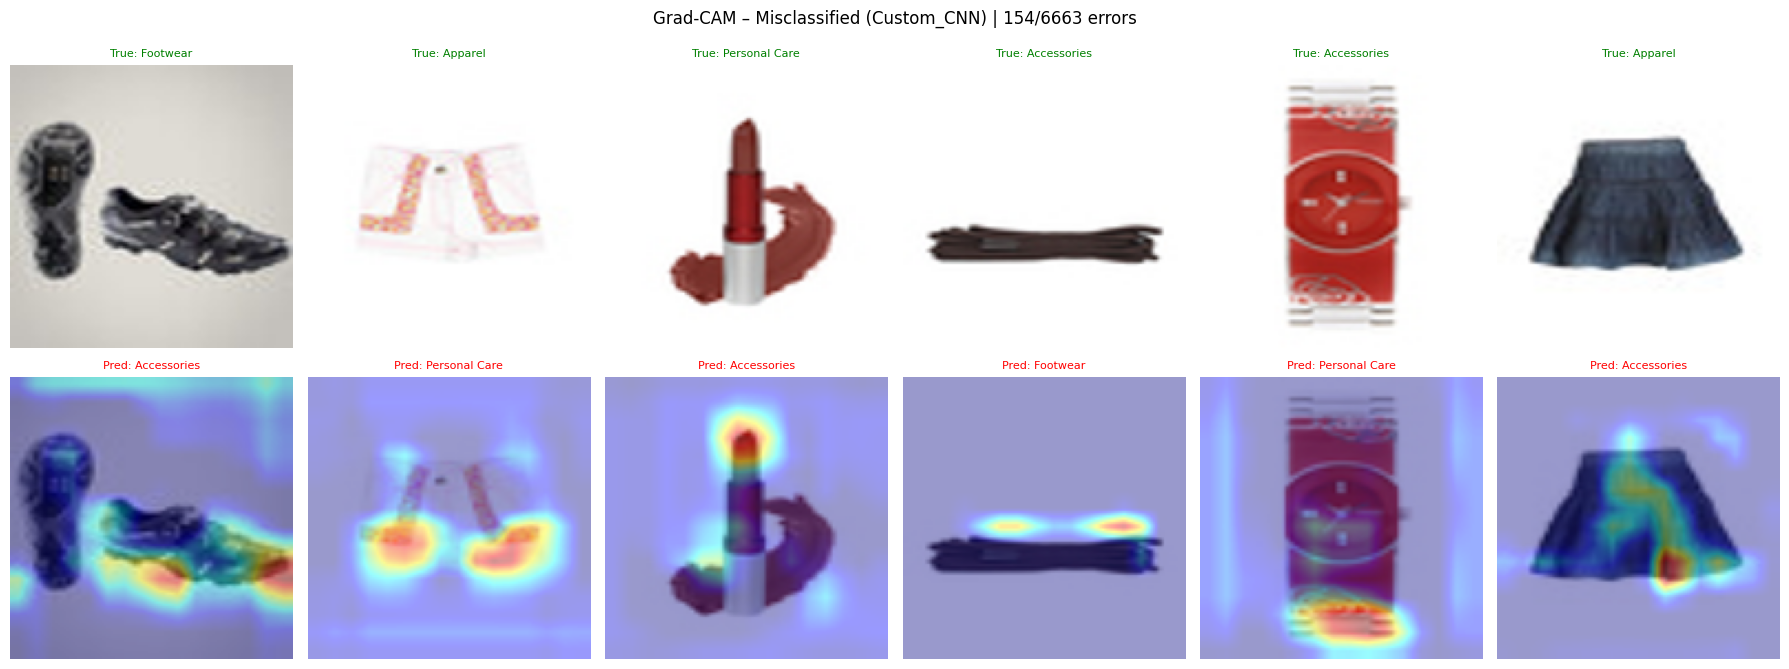

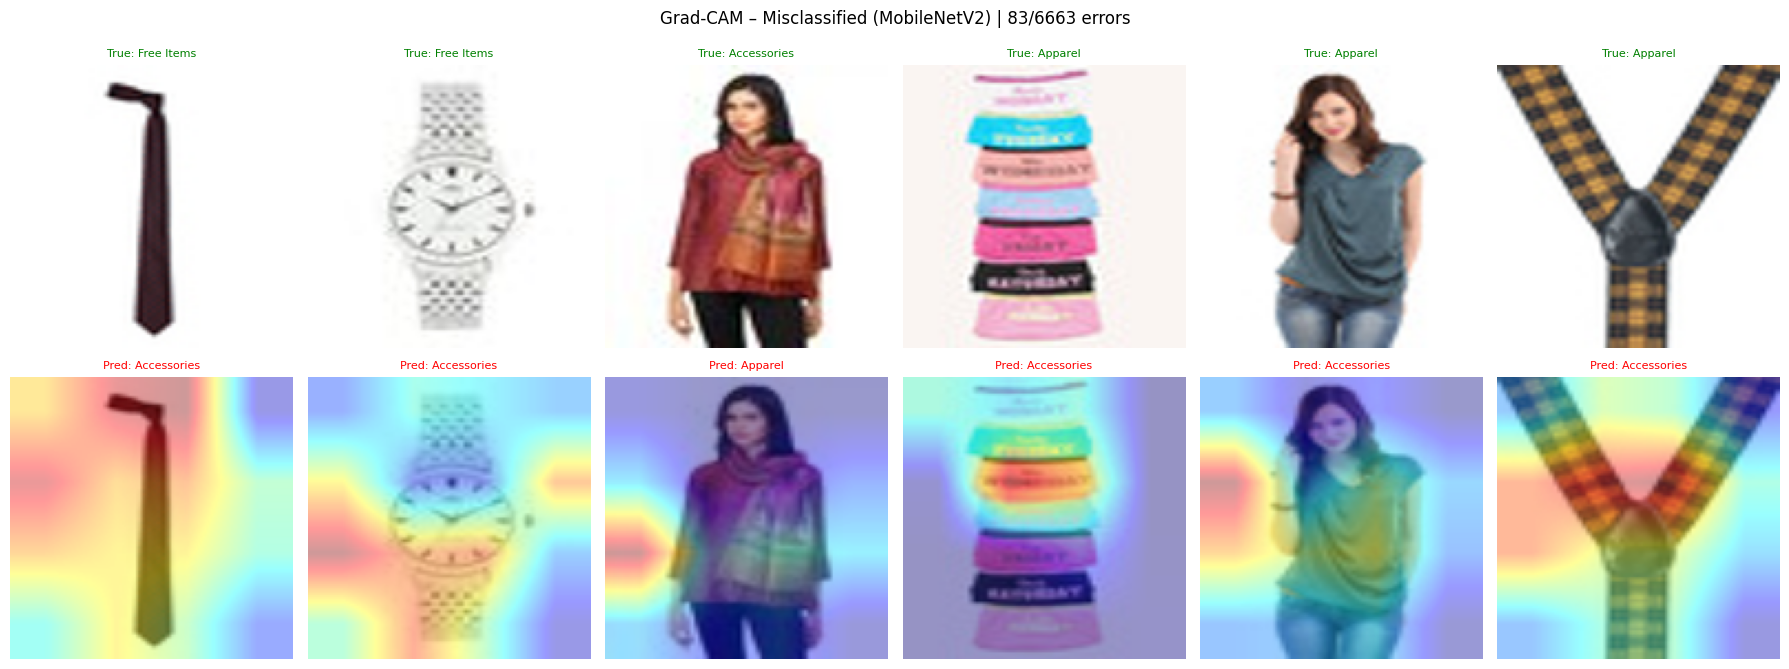

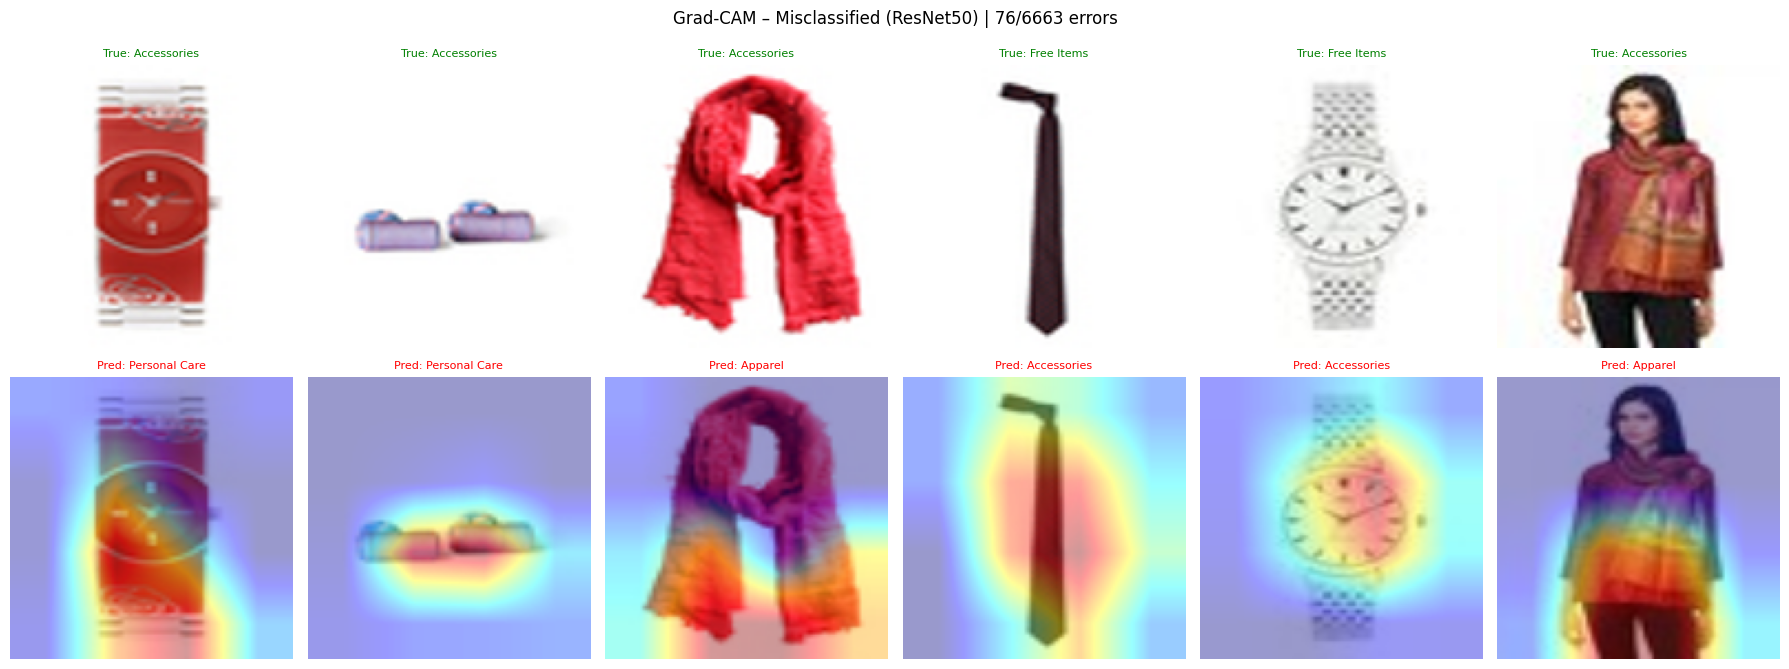

In [30]:
def gradcam_on_misclassified(model, results, test_df_reset, class_names,
                              gradcam_fn, model_name, output_dir,
                              n=6, tl_model=False):
    """
    Show Grad-CAM overlays on misclassified images.
    tl_model=True  → images loaded as 0-255 (backbone preprocess is inside model)
    tl_model=False → images loaded as 0-1   (CNN expects rescaled input)
    """
    y_true, y_pred = results['y_true'], results['y_pred']
    wrong_idx      = np.where(y_true != y_pred)[0][:n]
    if len(wrong_idx) == 0:
        print(f"{model_name}: no misclassified samples."); return

    cols = len(wrong_idx)
    fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 7))
    if cols == 1: axes = axes.reshape(2, 1)

    for col, idx in enumerate(wrong_idx):
        path    = test_df_reset.iloc[idx]['image_path']
        img_pil = Image.open(path).convert('RGB').resize(IMG_SIZE)
        img_np  = np.array(img_pil)

        # Scale for model input
        scale   = 1.0 if tl_model else 255.0
        img_arr = np.expand_dims(img_np / scale, 0).astype('float32')
        heatmap, _ = gradcam_fn(model, img_arr)
        overlay     = overlay_gradcam(path, heatmap)

        axes[0][col].imshow(img_pil)
        axes[0][col].set_title(f"True: {class_names[y_true[idx]]}", fontsize=8, color='green')
        axes[0][col].axis('off')
        axes[1][col].imshow(overlay)
        axes[1][col].set_title(f"Pred: {class_names[y_pred[idx]]}", fontsize=8, color='red')
        axes[1][col].axis('off')

    total_wrong = len(np.where(y_true != y_pred)[0])
    plt.suptitle(f'Grad-CAM – Misclassified ({model_name}) | {total_wrong}/{len(y_true)} errors',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_gradcam_misclassified.pdf', dpi=150, bbox_inches='tight')
    plt.show()


gradcam_on_misclassified(
    cnn_model,
    cnn_results,
    test_df_reset,
    CLASS_NAMES,
    lambda m, x: get_gradcam_heatmap(m, x, last_conv),
    "Custom_CNN",
    OUTPUT_DIR,
    tl_model=False
)
gradcam_on_misclassified(
    mobilenet_model,
    mobilenet_results,
    test_df_reset,
    CLASS_NAMES,
    get_gradcam_heatmap_mobilenet,
    "MobileNetV2",
    OUTPUT_DIR,
    tl_model=True
)
gradcam_on_misclassified(
    resnet_model,
    resnet_results,
    test_df_reset,
    CLASS_NAMES,
    get_gradcam_heatmap_resnet,
    "ResNet50",
    OUTPUT_DIR,
    tl_model=True
)

---
## 🔮 Step 15: SHAP Explanations

SHAP `GradientExplainer` assigns pixel-level attribution values: **red** pixels push the prediction toward the predicted class, **blue** pixels push against it.

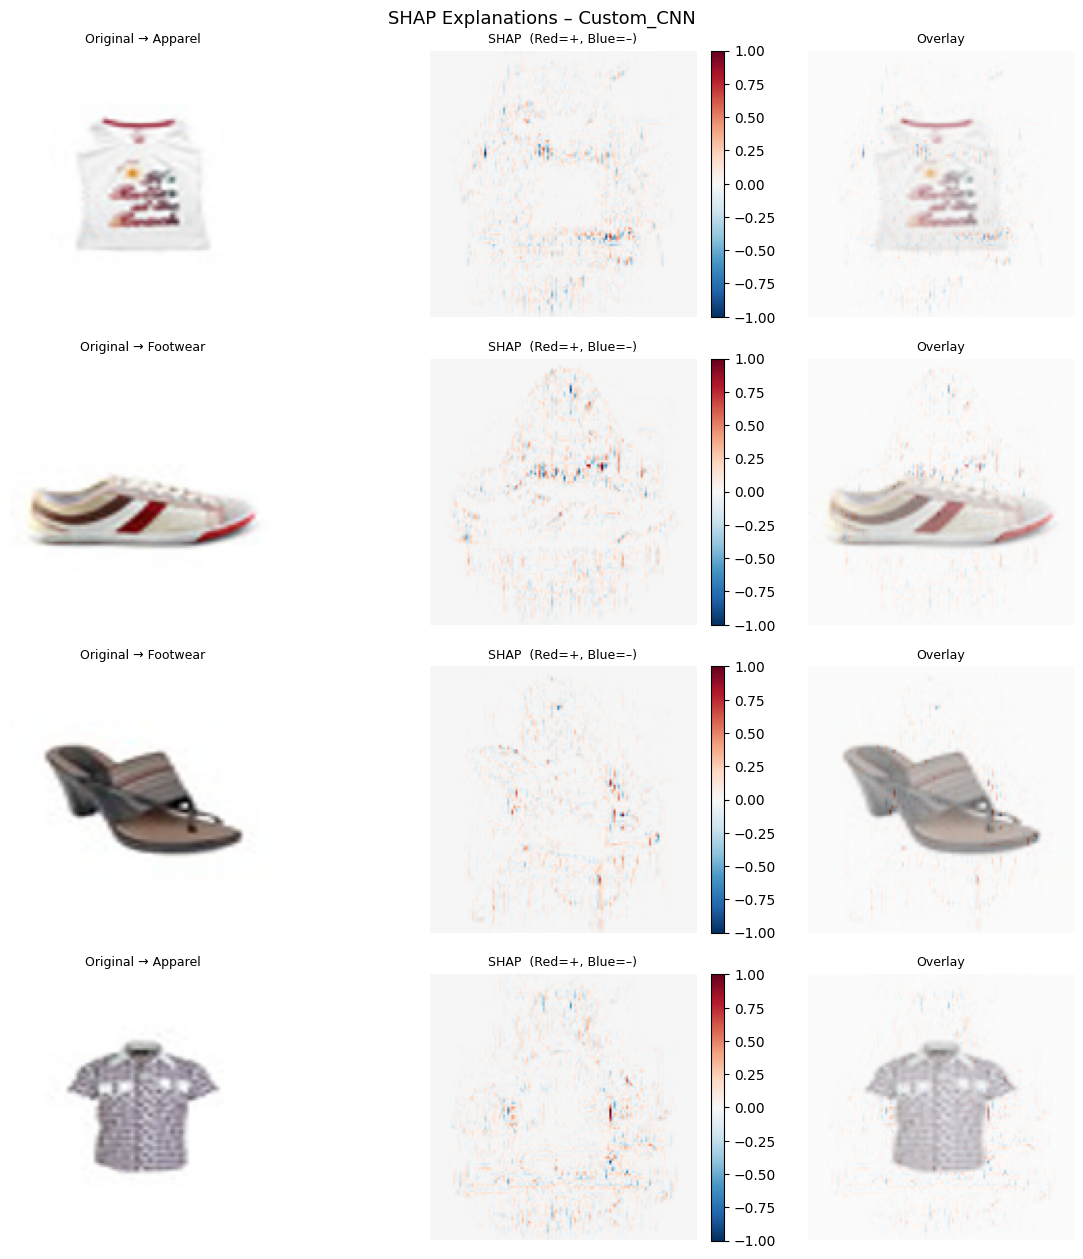

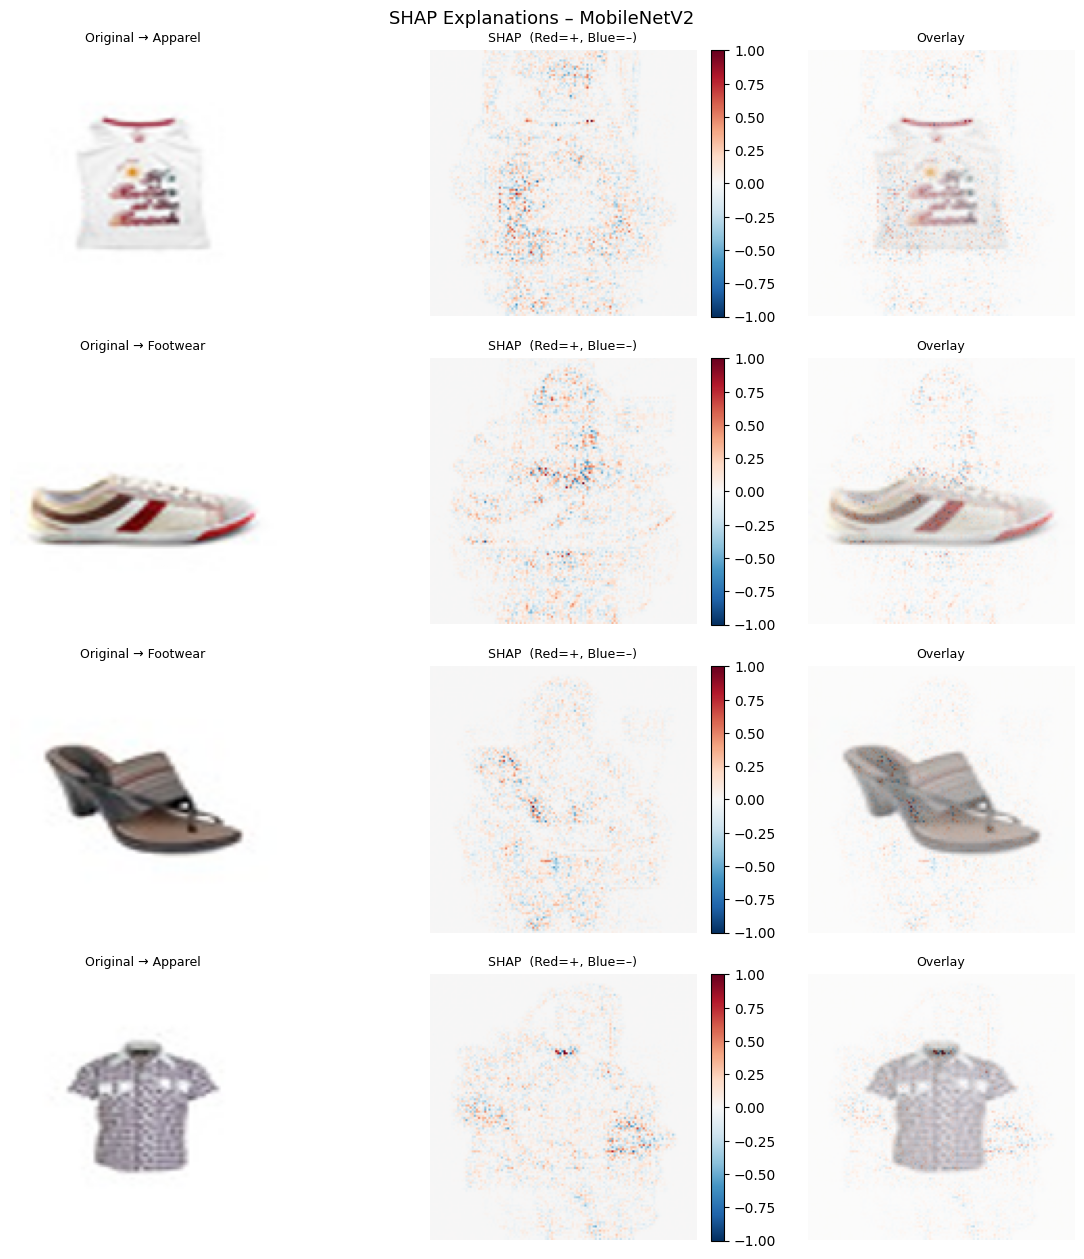

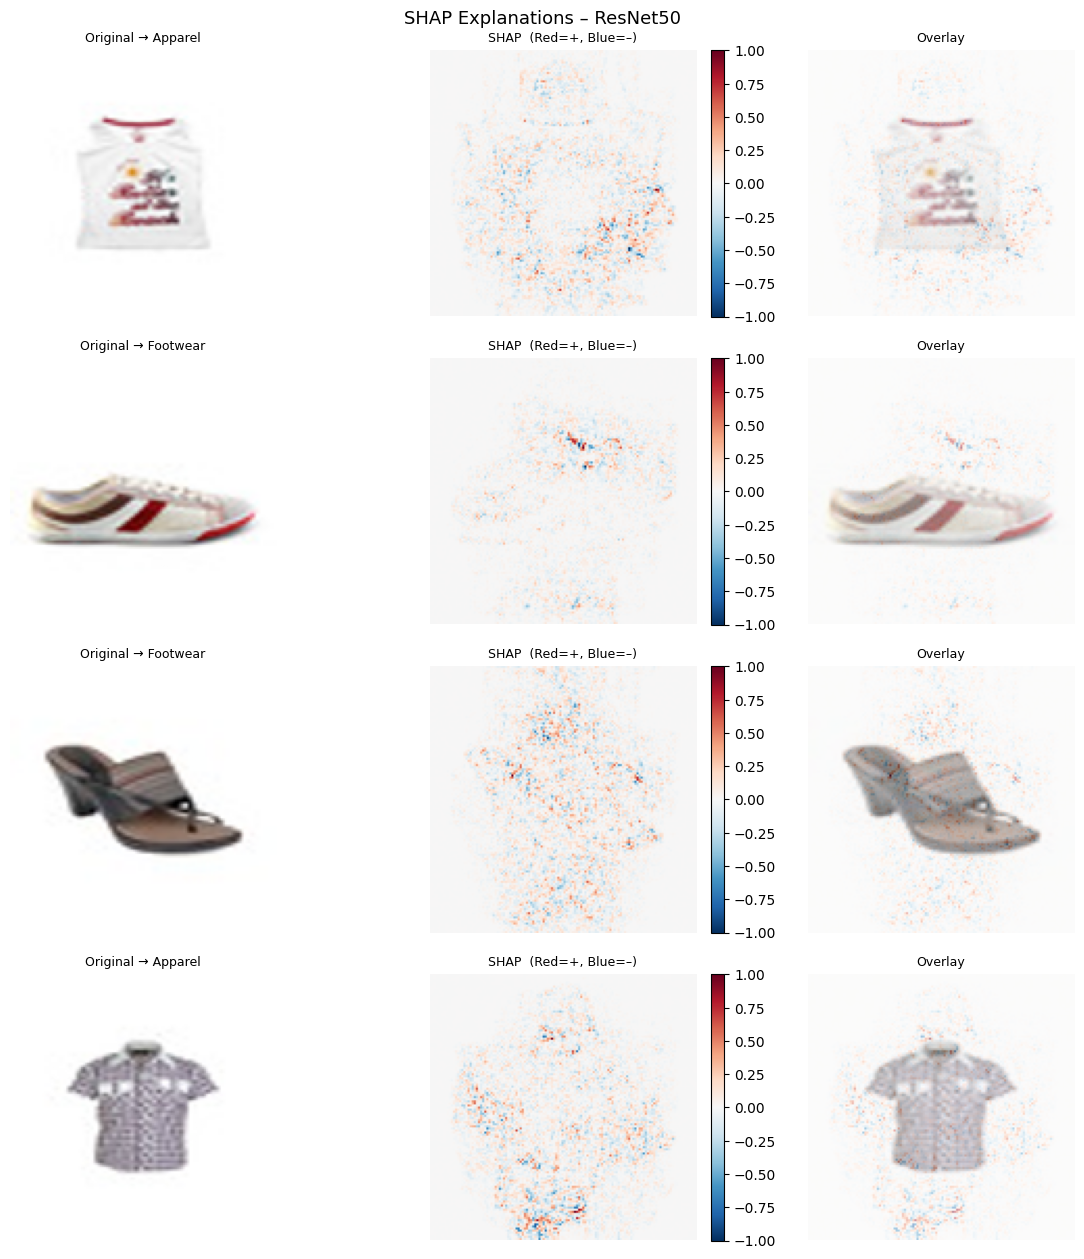

In [31]:
def run_shap(model, test_dataframe, class_names, model_name, output_dir,
             n_background=50, n_explain=4, tl_model=False):
    """
    SHAP GradientExplainer for image classification.
    tl_model=True  → images loaded as 0-255 (backbone preprocess inside model)
    tl_model=False → images loaded as 0-1   (CNN expects rescaled input)
    """
    scale = 1.0 if tl_model else 255.0

    def load_imgs(paths):
        return np.array([
            np.array(Image.open(p).convert('RGB').resize(IMG_SIZE)) / scale
            for p in paths
        ], dtype='float32')

    bg_paths  = test_dataframe.sample(n_background, random_state=SEED)['image_path'].tolist()
    exp_paths = test_dataframe.sample(n_explain, random_state=SEED+1)['image_path'].tolist()
    bg_imgs   = load_imgs(bg_paths)
    exp_imgs  = load_imgs(exp_paths)

    explainer   = shap.GradientExplainer(model, bg_imgs)
    shap_values = explainer.shap_values(exp_imgs)   # list[n_classes] of (n,H,W,C)
    
    preds       = np.argmax(model.predict(exp_imgs, verbose=0), axis=1)

    fig, axes = plt.subplots(n_explain, 3, figsize=(12, n_explain * 3.2))
    for i in range(n_explain):
        # Display image correctly for matplotlib
        disp_img = exp_imgs[i].astype(np.float32)

        if disp_img.max() > 1:
            disp_img = disp_img / 255.0

        disp_img = np.clip(disp_img, 0, 1)

        shap_map = shap_values[i, :, :, :, preds[i]].sum(axis=-1)   # (H, W)
        
        abs_max   = np.abs(shap_map).max() + 1e-8
        shap_norm = shap_map / abs_max                        # [-1, 1]

        axes[i][0].imshow(disp_img); axes[i][0].axis('off')
        axes[i][0].set_title(f"Original → {class_names[preds[i]]}", fontsize=9)

        im = axes[i][1].imshow(shap_norm, cmap='RdBu_r', vmin=-1, vmax=1)
        axes[i][1].set_title("SHAP  (Red=+, Blue=–)", fontsize=9); axes[i][1].axis('off')
        plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)

        blend = (disp_img * 0.55 + plt.cm.RdBu_r((shap_norm+1)/2)[...,:3] * 0.45).clip(0,1)
        axes[i][2].imshow(blend); axes[i][2].set_title("Overlay", fontsize=9); axes[i][2].axis('off')

    plt.suptitle(f'SHAP Explanations – {model_name}', fontsize=13)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_shap.pdf', dpi=150, bbox_inches='tight')
    plt.show()

run_shap(cnn_model,       test_df_reset, CLASS_NAMES, 'Custom_CNN',  OUTPUT_DIR, tl_model=False)
run_shap(mobilenet_model, test_df_reset, CLASS_NAMES, 'MobileNetV2', OUTPUT_DIR, tl_model=True)
run_shap(resnet_model,    test_df_reset, CLASS_NAMES, 'ResNet50',    OUTPUT_DIR, tl_model=True)


---
## 💾 Step 16: Save Models & Final Summary

In [32]:
cnn_model.save(       OUTPUT_DIR / 'custom_cnn_final.keras')
mobilenet_model.save( OUTPUT_DIR / 'mobilenet_final.keras')
resnet_model.save(    OUTPUT_DIR / 'resnet50_final.keras')
print("Models saved.")

# List output files
print(f"\nOutput files in {OUTPUT_DIR}:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:45s}  {f.stat().st_size/1024:7.1f} KB")


Models saved.

Output files in /kaggle/working/outputs:
  Custom_CNN_confusion_matrix.pdf                   16.8 KB
  Custom_CNN_gradcam_misclassified.pdf             244.9 KB
  Custom_CNN_report.csv                              0.3 KB
  Custom_CNN_shap.pdf                              281.2 KB
  MobileNetV2_confusion_matrix.pdf                  16.8 KB
  MobileNetV2_gradcam_misclassified.pdf            311.9 KB
  MobileNetV2_report.csv                             0.3 KB
  MobileNetV2_shap.pdf                             306.5 KB
  ResNet50_confusion_matrix.pdf                     17.0 KB
  ResNet50_gradcam_misclassified.pdf               271.1 KB
  ResNet50_report.csv                                0.3 KB
  ResNet50_shap.pdf                                302.5 KB
  augmented_samples.pdf                            504.4 KB
  best_cnn.keras                                  7762.8 KB
  best_mobilenet.keras                           25206.0 KB
  best_resnet50.keras                       

In [33]:
shutil.make_archive('/kaggle/working/project_outputs', 'zip', OUTPUT_DIR)
print("ZIP created: /kaggle/working/project_outputs.zip")


ZIP created: /kaggle/working/project_outputs.zip


In [34]:
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)
best = comparison.loc[comparison['Accuracy'].astype(float).idxmax(), 'Model']
print(f"\n✅ Best performing model: {best}")



  FINAL RESULTS SUMMARY
      Model  Accuracy  Precision  Recall  Macro F1 Training Time  Parameters
 Custom CNN    0.9769     0.7720  0.7797    0.7758       5868.6s      652069
MobileNetV2    0.9875     0.7874  0.7865    0.7869       2746.6s     2587205
   ResNet50    0.9886     0.7876  0.7886    0.7881       3853.2s    24113541

✅ Best performing model: ResNet50


---
## 🎯 Step 17: Live Product Classification Demo

In [35]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [36]:
# Load trained models
cnn_model = load_model("/kaggle/input/models/rajsinghh/custom/tensorflow2/default/1/custom_cnn_final.keras")

mobilenet_model = load_model("/kaggle/input/models/rajsinghh/custom/tensorflow2/default/1/mobilenet_final.keras")

resnet_model = load_model("/kaggle/input/models/rajsinghh/custom/tensorflow2/default/1/resnet50_final.keras")

In [37]:
# Class Names
CLASS_NAMES = [
    "Accessories",
    "Apparel",
    "Footwear",
    "Free Items",
    "Personal Care"
]

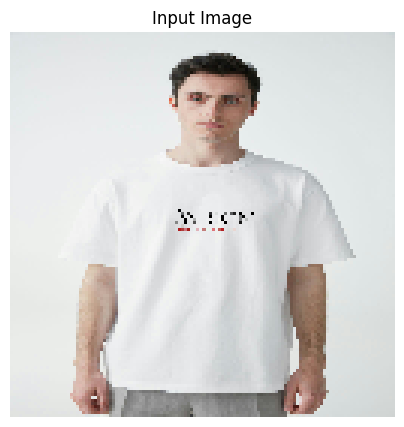

🎯 LIVE PRODUCT CLASSIFICATION RESULTS

🧠 Custom CNN
Prediction : Apparel
Confidence : 99.52%

📱 MobileNetV2
Prediction : Apparel
Confidence : 100.00%

🚀 ResNet50
Prediction : Apparel
Confidence : 100.00%


In [38]:
img_path = "/kaggle/input/datasets/rajsinghh/custom/img-3.jpg"
IMG_SIZE = (128, 128)

# Load image
img = image.load_img(img_path, target_size=IMG_SIZE)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Convert image
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

# Prepare inputs
x_cnn = x / 255.0
x_mobile = x.copy().astype("float32")     # preprocessing inside model
x_resnet = x.copy().astype("float32")     # preprocessing inside model

# Predict
cnn_pred = cnn_model.predict(x_cnn, verbose=0)
mobile_pred = mobilenet_model.predict(x_mobile, verbose=0)
resnet_pred = resnet_model.predict(x_resnet, verbose=0)

print("="*60)
print("🎯 LIVE PRODUCT CLASSIFICATION RESULTS")
print("="*60)

print(f"\n🧠 Custom CNN")
print(f"Prediction : {CLASS_NAMES[np.argmax(cnn_pred)]}")
print(f"Confidence : {np.max(cnn_pred)*100:.2f}%")

print(f"\n📱 MobileNetV2")
print(f"Prediction : {CLASS_NAMES[np.argmax(mobile_pred)]}")
print(f"Confidence : {np.max(mobile_pred)*100:.2f}%")

print(f"\n🚀 ResNet50")
print(f"Prediction : {CLASS_NAMES[np.argmax(resnet_pred)]}")
print(f"Confidence : {np.max(resnet_pred)*100:.2f}%")